<a href="https://colab.research.google.com/github/CikaAlfi/Rainfall_Prediction_using_Bi_LSTM_and_Attention_Mechanism/blob/main/Rainfall_Prediction_using_Bi_LSTM_and_Attention_Mechanism.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Prediksi Intensitas Curah Hujan Harian di Provinsi Jawa Barat
## Berdasarkan Data CHIRPS 3D (NetCDF) Menggunakan Bi-LSTM dan Attention Mechanism

---

In [ ]:
# ================================================================
# SEL 1: IMPORT LIBRARY
# ================================================================
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.colors as mcolors
import seaborn as sns
import xarray as xr

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Dense, Dropout, Bidirectional,
    LSTM, Lambda, Softmax, BatchNormalization
)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.preprocessing import MinMaxScaler, RobustScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import TimeSeriesSplit

!pip install pmdarima
import pmdarima as pm
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

warnings.filterwarnings('ignore')
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'
tf.get_logger().setLevel('ERROR')

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
})

print('✅ Library berhasil diimport')
print(f'   TensorFlow  : {tf.__version__}')
print(f'   NumPy       : {np.__version__}')
print(f'   Pandas      : {pd.__version__}')
print(f'   xarray      : {xr.__version__}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 18.8 MB/s eta 0:00:00
✅ Library berhasil diimport
   TensorFlow  : 2.20.0
   NumPy       : 2.0.2
   Pandas      : 2.2.2
   xarray      : 2025.12.0


## SEL 2 — Muat NetCDF 3D & ekstraksi fitur spasial harian

In [ ]:
# ================================================================
# SEL 2: LOAD NetCDF 3D CHIRPS  (sumber data UTAMA, bukan CSV)
# CSV lama mengandung baris rusak "00:00,0"; NetCDF dipakai karena bersih.
# ================================================================
from google.colab import files
uploaded = files.upload()                       # upload .nc
NC_FILE = 'CHIRPS_Jabar_26_Tahun_Gabungan.nc'

ds   = xr.open_dataset(NC_FILE)
prec = ds['precipitation_amount'].values         # (T, lat, lon)
N_DAYS = prec.shape[0]
times  = pd.date_range('2000-01-01', periods=N_DAYS, freq='D')
lats   = ds['latitude'].values
lons   = ds['longitude'].values

valid_mask = ~np.isnan(prec[0])                  # pixel di dalam Jawa Barat
prec_valid = prec[:, valid_mask]                 # (T, n_pixel_valid)

# --- CEK MISSING VALUE SEBENARNYA pada data NetCDF ---
# Missing = pixel valid (dalam Jawa Barat) tapi nilainya NaN di hari tertentu.
nan_per_day   = np.isnan(prec_valid).sum(axis=1)        # NaN per hari
n_hari_missing = int((nan_per_day > 0).sum())           # jumlah hari yg punya NaN
total_nan      = int(np.isnan(prec_valid).sum())        # total sel NaN

# Sub-region (4 kuadran) untuk konteks topografi utara/selatan
lat_grid, lon_grid = np.meshgrid(lats, lons, indexing='ij')
vlat, vlon = lat_grid[valid_mask], lon_grid[valid_mask]
lat_mid, lon_mid = (lats.min()+lats.max())/2, (lons.min()+lons.max())/2
mNW=(vlat>=lat_mid)&(vlon<=lon_mid); mNE=(vlat>=lat_mid)&(vlon>lon_mid)
mSW=(vlat< lat_mid)&(vlon<=lon_mid); mSE=(vlat< lat_mid)&(vlon>lon_mid)

# Agregasi spasial pakai nanmean/nanstd agar NaN tidak merusak rata-rata
df_raw = pd.DataFrame({
    'DateTime': times,
    'mean'    : np.nanmean(prec_valid, axis=1),
    'std'     : np.nanstd(prec_valid, axis=1),
    'max'     : np.nanmax(prec_valid, axis=1),
    'p75'     : np.nanpercentile(prec_valid, 75, axis=1),
    'p90'     : np.nanpercentile(prec_valid, 90, axis=1),
    'pct_rain': (prec_valid > 0.1).mean(axis=1),
    'wet_area': (prec_valid > 10.0).mean(axis=1),
    'reg_NW'  : np.nanmean(prec_valid[:,mNW], axis=1),
    'reg_NE'  : np.nanmean(prec_valid[:,mNE], axis=1),
    'reg_SW'  : np.nanmean(prec_valid[:,mSW], axis=1),
    'reg_SE'  : np.nanmean(prec_valid[:,mSE], axis=1),
})

# --- Penanganan nilai hilang yang BENAR (bukan isi nol) ---
# (a) celah tanggal pada kalender harian -> reindex
# (b) hari yang seluruh nilainya NaN setelah agregasi -> interpolasi waktu
df_raw = df_raw.set_index('DateTime').asfreq('D')
n_gap_tanggal = int(df_raw['mean'].isna().sum())            # celah kalender
df_raw = df_raw.interpolate('time').bfill().ffill().reset_index()

print('=' * 60)
print('RINGKASAN DATA & PENANGANAN MISSING VALUE (NetCDF)')
print('=' * 60)
print(f'Hari total            : {N_DAYS:,}  ({times[0].date()} -> {times[-1].date()})')
print(f'Pixel valid (Jabar)   : {valid_mask.sum():,}')
print(f'Sel NaN dalam NetCDF  : {total_nan:,}')
print(f'Hari mengandung NaN   : {n_hari_missing:,}')
print(f'Celah tanggal kalender: {n_gap_tanggal:,}')
print(f'Metode pengisian      : interpolasi waktu (BUKAN diisi 0 mm)')
print('=' * 60)
df_raw.head()

Saving CHIRPS_Jabar_26_Tahun_Gabungan.nc to CHIRPS_Jabar_26_Tahun_Gabungan.nc
RINGKASAN DATA & PENANGANAN MISSING VALUE (NetCDF)
Hari total            : 9,497  (2000-01-01 -> 2025-12-31)
Pixel valid (Jabar)   : 1,221
Sel NaN dalam NetCDF  : 0
Hari mengandung NaN   : 0
Celah tanggal kalender: 0
Metode pengisian      : interpolasi waktu (BUKAN diisi 0 mm)


,DateTime,mean,std,max,p75,p90,pct_rain,wet_area,reg_NW,reg_NE,reg_SW,reg_SE
0,2000-01-01,6.784883,6.234967,24.323488,11.010564,16.693651,0.689599,0.294840,1.364081,4.929120,7.092294,12.956335
1,2000-01-02,10.154709,5.145454,24.229637,12.851171,17.865705,0.956593,0.513514,7.495068,8.285447,10.209958,13.890481
2,2000-01-03,9.550145,4.322358,21.234961,12.248691,15.050973,0.947584,0.547093,7.571838,8.772910,11.244171,10.776178
3,2000-01-04,9.391663,5.051422,33.644032,11.679554,15.994354,0.967240,0.443898,6.830060,8.074990,12.758422,10.376089
4,2000-01-05,4.916105,5.216374,33.475307,7.669801,11.625151,0.597052,0.168714,7.418968,2.768665,2.953929,5.335548


## SEL 3 — EDA: distribusi, musiman, autokorelasi (justifikasi target 3-hari)

Autokorelasi rata-rata spasial harian:
  lag   1: 0.565
  lag   2: 0.444
  lag   3: 0.383
  lag   5: 0.305
  lag   7: 0.293
  lag  14: 0.242
  lag  30: 0.198

Skewness: 1.43  |  hari <0.1mm: 1376  |  hari >50mm: 11


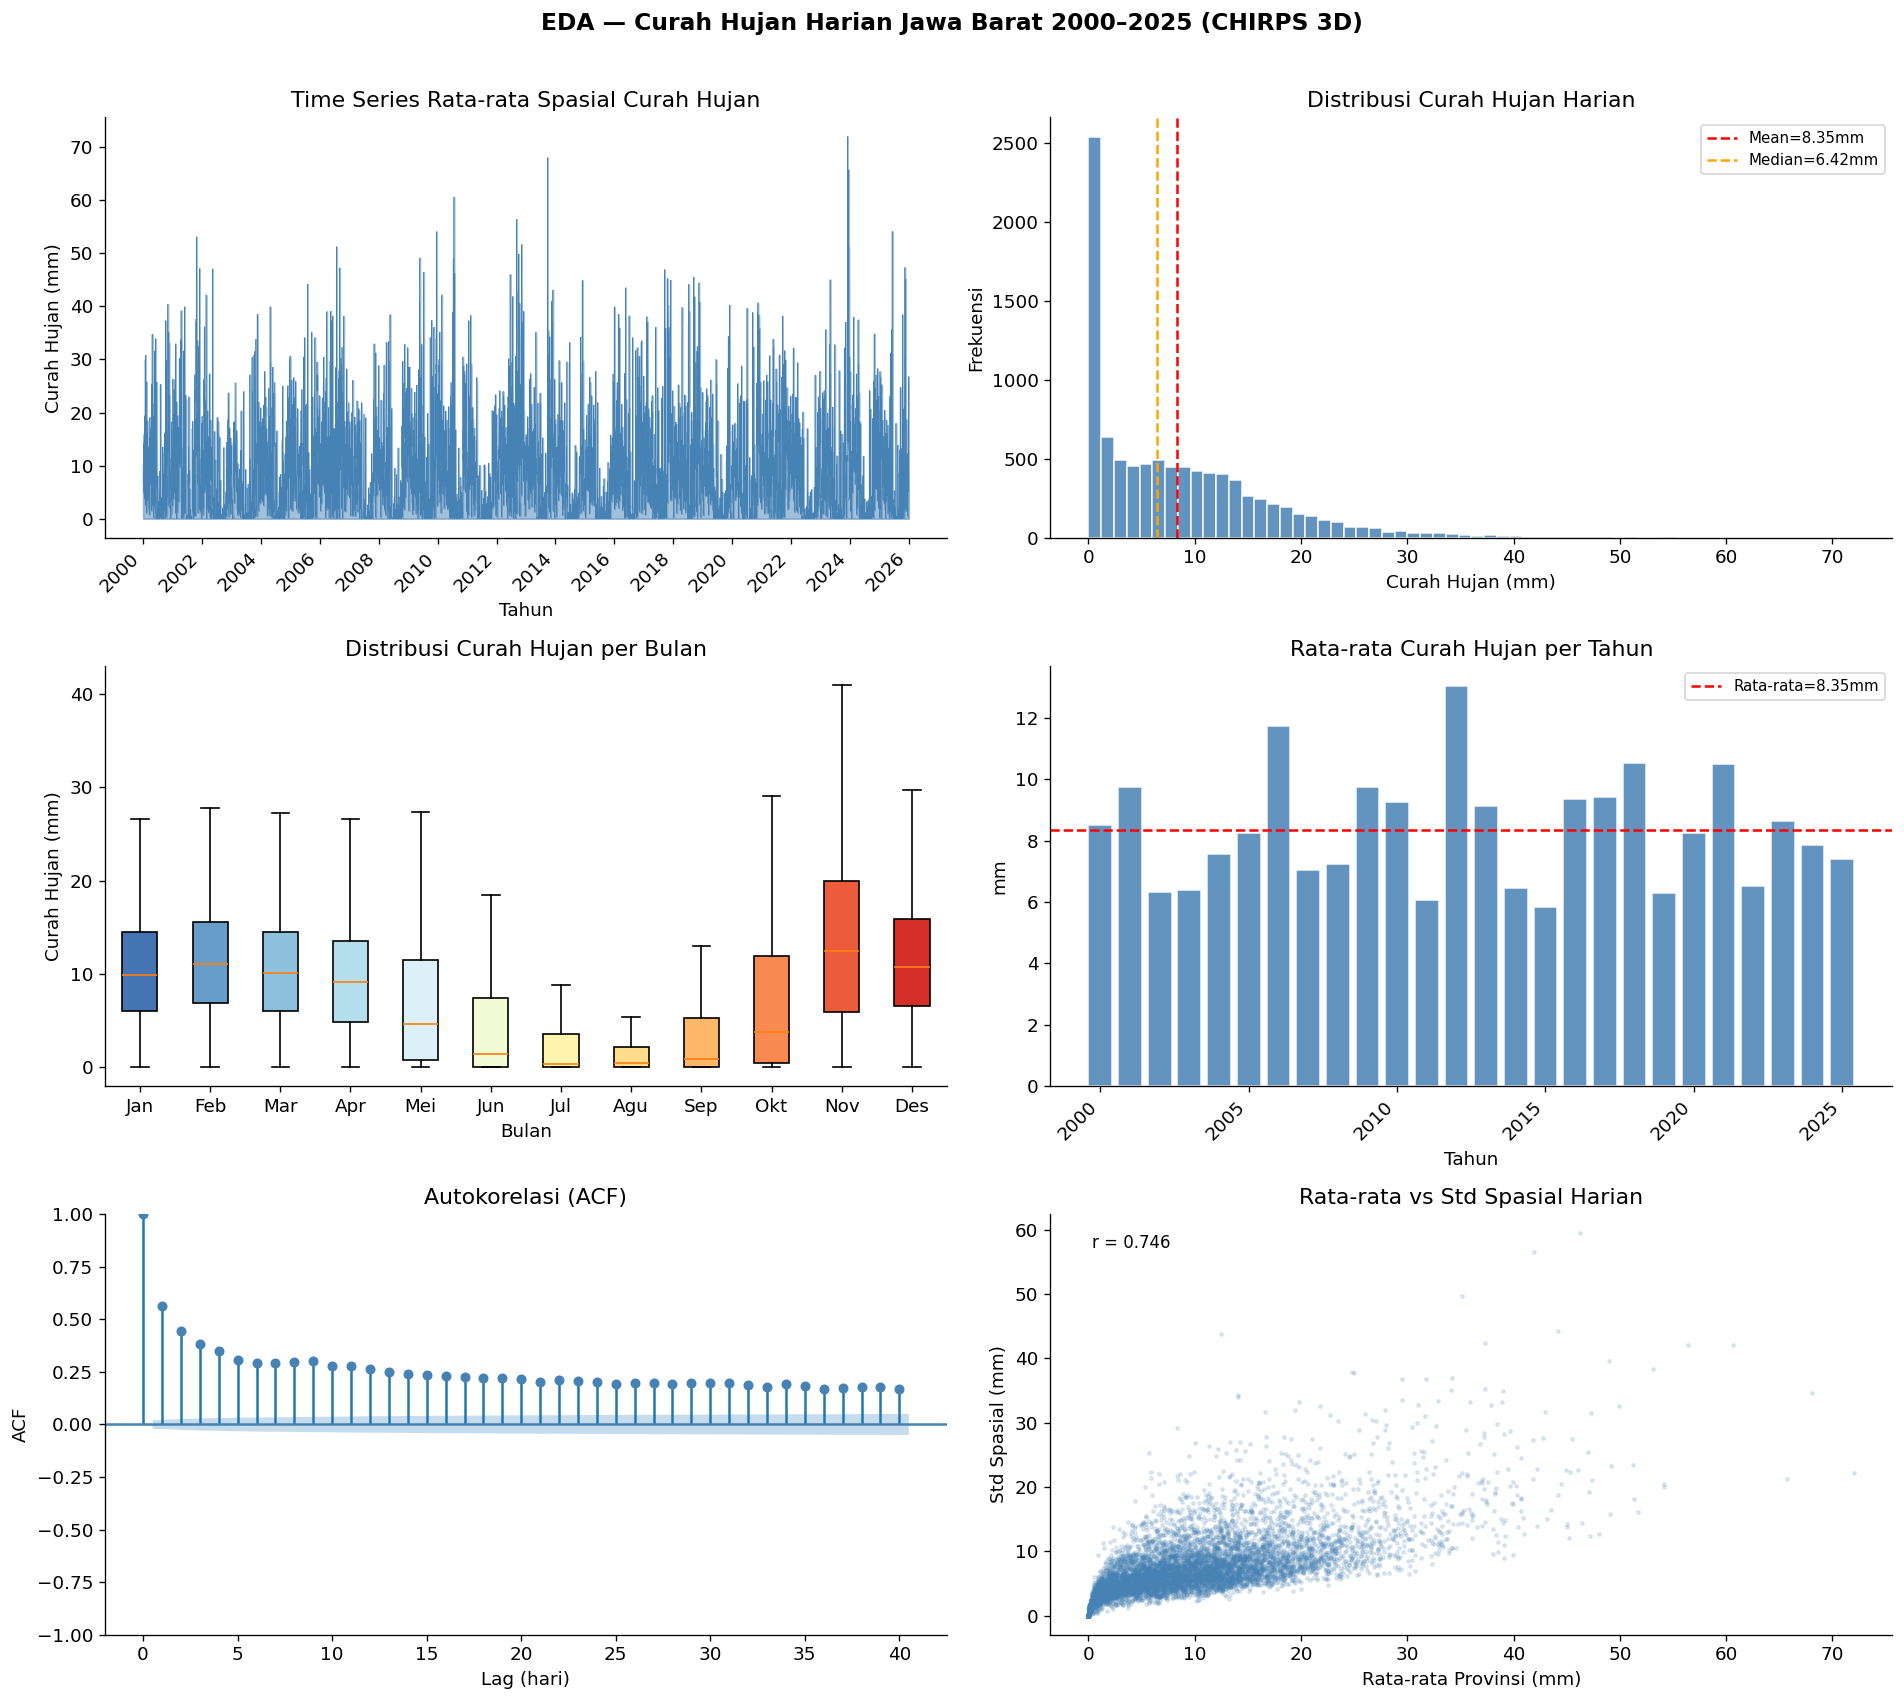

✅ plot_01_eda.png tersimpan


In [ ]:
# ================================================================
# SEL 3: EDA — kenapa target harian sulit, target 3-hari lebih layak
# ================================================================
df = df_raw.copy()
df['Year']=df['DateTime'].dt.year; df['Month']=df['DateTime'].dt.month
s = df['mean']

acf_lags=[1,2,3,5,7,14,30]
acf_vals=[s.autocorr(l) for l in acf_lags]
print('Autokorelasi rata-rata spasial harian:')
for l,a in zip(acf_lags,acf_vals): print(f'  lag {l:>3}: {a:.3f}')
print(f'\nSkewness: {s.skew():.2f}  |  hari <0.1mm: {(s<0.1).sum()}  |  hari >50mm: {(s>50).sum()}')

# ================================================================
# SEL 3A: EDA — TIME SERIES & DISTRIBUSI
# ================================================================
df = df_raw.copy()
df['Year']   = df['DateTime'].dt.year
df['Month']  = df['DateTime'].dt.month
df['Season'] = df['Month'].apply(
    lambda m: 'Musim Hujan' if m in [11,12,1,2,3] else 'Musim Kemarau'
)

fig, axes = plt.subplots(3, 2, figsize=(16, 14))
fig.suptitle('EDA — Curah Hujan Harian Jawa Barat 2000–2025 (CHIRPS 3D)',
             fontsize=14, fontweight='bold', y=1.01)

# Time series
ax = axes[0,0]
ax.fill_between(df['DateTime'], df['mean'], alpha=0.5, color='steelblue')
ax.plot(df['DateTime'], df['mean'], linewidth=0.3, color='steelblue')
ax.xaxis.set_major_locator(mdates.YearLocator(2))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.set_title('Time Series Rata-rata Spasial Curah Hujan')
ax.set_xlabel('Tahun'); ax.set_ylabel('Curah Hujan (mm)')
plt.setp(ax.get_xticklabels(), rotation=45, ha='right')

# Distribusi histogram
ax2 = axes[0,1]
ax2.hist(df['mean'], bins=60, color='steelblue', edgecolor='white', alpha=0.85)
ax2.axvline(df['mean'].mean(), color='red', linestyle='--', lw=1.5,
            label=f"Mean={df['mean'].mean():.2f}mm")
ax2.axvline(df['mean'].median(), color='orange', linestyle='--', lw=1.5,
            label=f"Median={df['mean'].median():.2f}mm")
ax2.set_title('Distribusi Curah Hujan Harian')
ax2.set_xlabel('Curah Hujan (mm)'); ax2.set_ylabel('Frekuensi')
ax2.legend(fontsize=9)

# Box plot per bulan
ax3 = axes[1,0]
month_labels = ['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agu','Sep','Okt','Nov','Des']
data_per_bulan = [df[df['Month']==m]['mean'].values for m in range(1,13)]
bp = ax3.boxplot(data_per_bulan, patch_artist=True, showfliers=False)
cmap = plt.cm.RdYlBu_r(np.linspace(0.1, 0.9, 12))
for patch, color in zip(bp['boxes'], cmap): patch.set_facecolor(color)
ax3.set_xticklabels(month_labels)
ax3.set_title('Distribusi Curah Hujan per Bulan')
ax3.set_xlabel('Bulan'); ax3.set_ylabel('Curah Hujan (mm)')

# Rata-rata tahunan
ax4 = axes[1,1]
yearly = df.groupby('Year')['mean'].mean()
ax4.bar(yearly.index, yearly.values, color='steelblue', alpha=0.85, edgecolor='white')
ax4.axhline(yearly.mean(), color='red', linestyle='--', lw=1.5,
            label=f'Rata-rata={yearly.mean():.2f}mm')
ax4.set_title('Rata-rata Curah Hujan per Tahun')
ax4.set_xlabel('Tahun'); ax4.set_ylabel('mm')
ax4.legend(fontsize=9)
plt.setp(ax4.get_xticklabels(), rotation=45, ha='right')

# ACF
ax5 = axes[2,0]
plot_acf(df['mean'], ax=ax5, lags=40, alpha=0.05, color='steelblue')
ax5.set_title('Autokorelasi (ACF)')
ax5.set_xlabel('Lag (hari)'); ax5.set_ylabel('ACF')

# Variabilitas spasial harian
ax6 = axes[2,1]
ax6.scatter(df['mean'], df['std'], alpha=0.15, s=4, color='steelblue')
ax6.set_title('Rata-rata vs Std Spasial Harian')
ax6.set_xlabel('Rata-rata Provinsi (mm)'); ax6.set_ylabel('Std Spasial (mm)')
corr = df['mean'].corr(df['std'])
ax6.text(0.05, 0.92, f'r = {corr:.3f}', transform=ax6.transAxes, fontsize=10)

plt.tight_layout()
plt.savefig('plot_01_eda.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ plot_01_eda.png tersimpan')

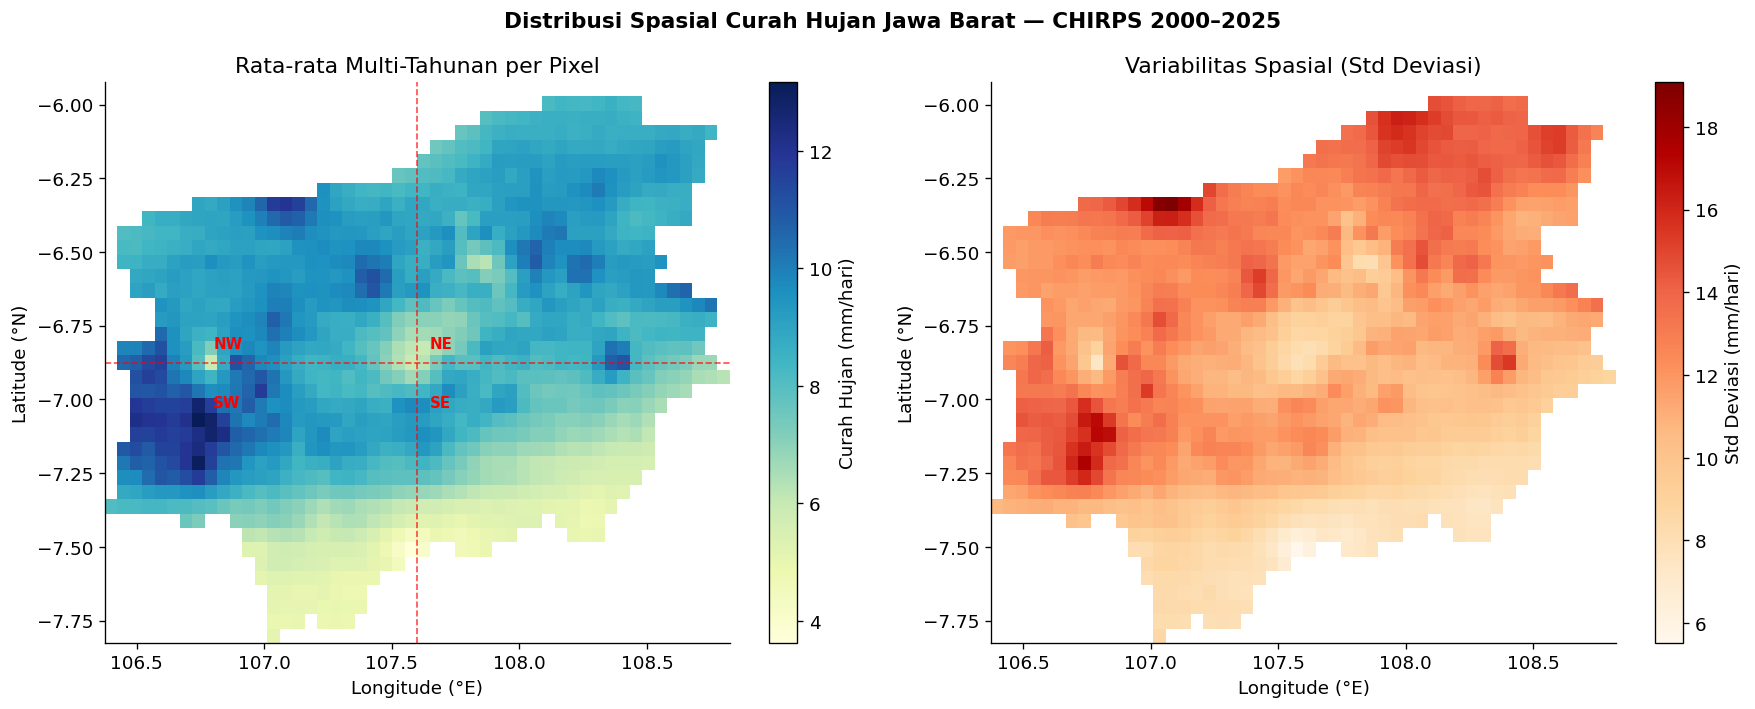

✅ plot_02_peta_spasial.png tersimpan


In [ ]:
# ================================================================
# SEL 3B: EDA — PETA SPASIAL RATA-RATA CURAH HUJAN
# ================================================================
# Hitung rata-rata multi-tahunan per pixel
mean_spatial = np.full((len(lats), len(lons)), np.nan)
mean_spatial[valid_mask] = prec_valid.mean(axis=0)

std_spatial = np.full((len(lats), len(lons)), np.nan)
std_spatial[valid_mask] = prec_valid.std(axis=0)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Distribusi Spasial Curah Hujan Jawa Barat — CHIRPS 2000–2025',
             fontsize=13, fontweight='bold')

extent = [lons.min(), lons.max(), lats.min(), lats.max()]

im1 = axes[0].imshow(mean_spatial, origin='upper', extent=extent,
                      cmap='YlGnBu', aspect='auto')
plt.colorbar(im1, ax=axes[0], label='Curah Hujan (mm/hari)')
axes[0].set_title('Rata-rata Multi-Tahunan per Pixel')
axes[0].set_xlabel('Longitude (°E)'); axes[0].set_ylabel('Latitude (°N)')
axes[0].axhline(lat_mid, color='red', linestyle='--', lw=1, alpha=0.7)
axes[0].axvline(lon_mid, color='red', linestyle='--', lw=1, alpha=0.7)
axes[0].text(lon_mid-0.8, lat_mid+0.05, 'NW', color='red', fontsize=9, fontweight='bold')
axes[0].text(lon_mid+0.05, lat_mid+0.05, 'NE', color='red', fontsize=9, fontweight='bold')
axes[0].text(lon_mid-0.8, lat_mid-0.15, 'SW', color='red', fontsize=9, fontweight='bold')
axes[0].text(lon_mid+0.05, lat_mid-0.15, 'SE', color='red', fontsize=9, fontweight='bold')

im2 = axes[1].imshow(std_spatial, origin='upper', extent=extent,
                      cmap='OrRd', aspect='auto')
plt.colorbar(im2, ax=axes[1], label='Std Deviasi (mm/hari)')
axes[1].set_title('Variabilitas Spasial (Std Deviasi)')
axes[1].set_xlabel('Longitude (°E)'); axes[1].set_ylabel('Latitude (°N)')

plt.tight_layout()
plt.savefig('plot_02_peta_spasial.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ plot_02_peta_spasial.png tersimpan')

## SEL 4 — Feature engineering (anti-leakage) & definisi TARGET 3-hari

In [ ]:
# ================================================================
# SEL 4: FEATURE ENGINEERING + TARGET INTENSITAS 3-HARI
# Anti-leakage: semua rolling/lag pakai shift(1).
# TARGET y[t] = rata-rata hujan hari (t+1, t+2, t+3)  -> selalu MASA DEPAN.
# ================================================================
df_feat = df_raw.copy()

# Fitur siklikal musiman
doy = df_feat['DateTime'].dt.dayofyear
df_feat['sin_day']=np.sin(2*np.pi*doy/365.25)
df_feat['cos_day']=np.cos(2*np.pi*doy/365.25)
df_feat['sin_mon']=np.sin(2*np.pi*df_feat['DateTime'].dt.month/12)
df_feat['cos_mon']=np.cos(2*np.pi*df_feat['DateTime'].dt.month/12)

BASE=['mean','std','max','p75','p90','pct_rain','wet_area','reg_NW','reg_NE','reg_SW','reg_SE']
for c in BASE:
    sh=df_feat[c].shift(1)                       # shift(1) = historis, anti bocor
    df_feat[f'r7_{c}']  = sh.rolling(7).mean()
    df_feat[f'r14_{c}'] = sh.rolling(14).mean()
    df_feat[f'r30_{c}'] = sh.rolling(30).mean()

# ---- TARGET: intensitas curah hujan 3 hari ke depan ----
HORIZON = 3
df_feat['target'] = df_feat['mean'].shift(-1).rolling(HORIZON).mean()   # mean(t+1..t+3)

df_feat = df_feat.dropna().reset_index(drop=True)

TARGET_COL='target'
FEATURE_COLS=(['sin_day','cos_day','sin_mon','cos_mon']+BASE+
              [f'r7_{c}' for c in BASE]+[f'r14_{c}' for c in BASE]+[f'r30_{c}' for c in BASE])
N_FEATURES=len(FEATURE_COLS)
print(f'Fitur input : {N_FEATURES}')
print(f'Sampel      : {len(df_feat):,}')
print(f'Target      : rata-rata curah hujan {HORIZON} hari ke depan (mm/hari)')
print(f'Rentang     : {df_feat.DateTime.min().date()} -> {df_feat.DateTime.max().date()}')


Fitur input : 48
Sampel      : 9,466
Target      : rata-rata curah hujan 3 hari ke depan (mm/hari)
Rentang     : 2000-01-31 -> 2025-12-30


## SEL 5 — Sliding window & split kronologis 80/10/10

In [ ]:
# ================================================================
# SEL 5: SEQUENCES + SPLIT KRONOLOGIS (tanpa shuffle)
# ================================================================
TIMESTEP = 30                                    # 30 hari historis

def make_seq(Xa, ya, T):
    X,y=[],[]
    for i in range(len(Xa)-T):
        X.append(Xa[i:i+T]); y.append(ya[i+T])
    return np.array(X), np.array(y)

Xa = df_feat[FEATURE_COLS].values
ya = df_feat[TARGET_COL].values
dates_seq = df_feat['DateTime'].values[TIMESTEP:]
X_all, y_all = make_seq(Xa, ya, TIMESTEP)

N=len(X_all); tr=int(.8*N); va=int(.9*N)
X_train,y_train=X_all[:tr],y_all[:tr]
X_val,  y_val  =X_all[tr:va],y_all[tr:va]
X_test, y_test =X_all[va:],  y_all[va:]
dtr,dva,dte=dates_seq[:tr],dates_seq[tr:va],dates_seq[va:]

print(f'Total sequences {N:,} | shape {X_all.shape}')
for nm,xx,dd in [('Train',X_train,dtr),('Val',X_val,dva),('Test',X_test,dte)]:
    print(f'  {nm:5} {len(xx):>5,} | {pd.Timestamp(dd[0]).date()} -> {pd.Timestamp(dd[-1]).date()}')


Total sequences 9,436 | shape (9436, 30, 48)
  Train 7,548 | 2000-03-01 -> 2020-10-29
  Val     944 | 2020-10-30 -> 2023-05-31
  Test    944 | 2023-06-01 -> 2025-12-30


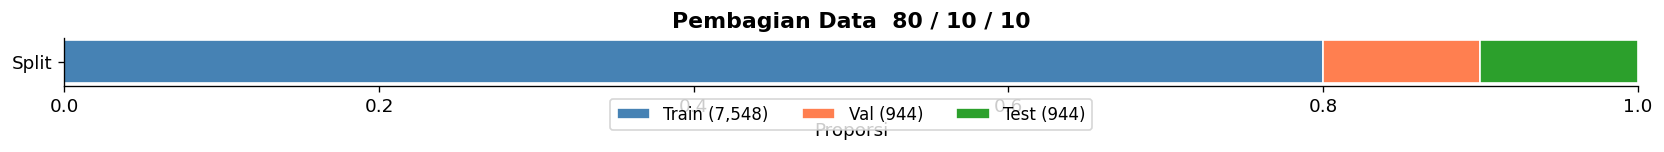

Semua plot viz_V1..V8 tersimpan sebagai PNG.


In [ ]:
C_BILSTM = '#4682B4' # SteelBlue
C_ARIMA  = '#FF7F50' # Coral
C_GREEN = '#2CA02C' # Green

# ================================================================
# SEL V8: VISUAL PEMBAGIAN DATA 80/10/10 (kronologis)
# ================================================================
fig, ax = plt.subplots(figsize=(14, 2.0))
tot = len(X_train) + len(X_val) + len(X_test)
ax.barh(['Split'], [len(X_train)/tot], color=C_BILSTM, edgecolor='white', label=f'Train ({len(X_train):,})')
ax.barh(['Split'], [len(X_val)/tot],   left=[len(X_train)/tot], color=C_ARIMA, edgecolor='white', label=f'Val ({len(X_val):,})')
ax.barh(['Split'], [len(X_test)/tot],  left=[(len(X_train)+len(X_val))/tot], color=C_GREEN, edgecolor='white', label=f'Test ({len(X_test):,})')
ax.set_xlim(0,1); ax.set_xlabel('Proporsi'); ax.legend(loc='center', ncol=3, fontsize=10, bbox_to_anchor=(0.5,-0.6))
ax.set_title('Pembagian Data  80 / 10 / 10', fontweight='bold')
plt.tight_layout()
plt.savefig('viz_V8_split_data.png', dpi=150, bbox_inches='tight')
plt.show()
print('Semua plot viz_V1..V8 tersimpan sebagai PNG.')

## SEL 6 — Normalisasi

In [ ]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# ================================================================
# SEL 6: NORMALISASI MinMaxScaler
# ATURAN: scaler di-fit HANYA pada data TRAIN.
#         Val dan Test hanya di-transform (bukan fit).
#         Ini mencegah informasi dari val/test bocor ke proses normalisasi.
# ================================================================

scaler_X = MinMaxScaler(feature_range=(0, 1))
scaler_y = MinMaxScaler(feature_range=(0, 1))

# Reshape 3D -> 2D untuk scaling, lalu kembalikan ke 3D
X_train_2d = X_train.reshape(-1, N_FEATURES)
X_val_2d   = X_val.reshape(-1, N_FEATURES)
X_test_2d  = X_test.reshape(-1, N_FEATURES)

X_train_scaled = scaler_X.fit_transform(X_train_2d).reshape(X_train.shape)
X_val_scaled   = scaler_X.transform(X_val_2d).reshape(X_val.shape)
X_test_scaled  = scaler_X.transform(X_test_2d).reshape(X_test.shape)

y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1))
y_val_scaled   = scaler_y.transform(y_val.reshape(-1, 1))
# y_test tidak di-scale; kita inverse_transform prediksi ke skala asli

print('=' * 65)
print('NORMALISASI MinMaxScaler')
print('=' * 65)
print(f'scaler_X fit pada : X_train ({len(X_train):,} sampel × {TIMESTEP} timestep × {N_FEATURES} fitur)')
print(f'scaler_y fit pada : y_train ({len(y_train):,} sampel)')
print()
print(f'Rentang y_train sebelum normalisasi : [{y_train.min():.4f}, {y_train.max():.4f}] mm')
print(f'Rentang y_train setelah normalisasi : [{y_train_scaled.min():.4f}, {y_train_scaled.max():.4f}]')
print()
print(f'Shape X_train_scaled : {X_train_scaled.shape}')
print(f'Shape X_val_scaled   : {X_val_scaled.shape}')
print(f'Shape X_test_scaled  : {X_test_scaled.shape}')
print(f'Shape y_train_scaled : {y_train_scaled.shape}')
print('=' * 65)

# Tabel contoh normalisasi (8 data pertama)
tbl_first_8_days = pd.DataFrame({
    'Tanggal'             : pd.to_datetime(dtr[:8]).strftime('%Y-%m-%d'),
    'Curah Hujan (mm)'    : y_train[:8].round(4),
    'Setelah Normalisasi' : y_train_scaled[:8, 0].round(6),
})
print('Contoh 8 data pertama:')
print(tbl_first_8_days.to_string(index=False))

# Tabel contoh normalisasi (8 data terakhir)
tbl_last_8_days = pd.DataFrame({
    'Tanggal'             : pd.to_datetime(dtr[-8:]).strftime('%Y-%m-%d'),
    'Curah Hujan (mm)'    : y_train[-8:].round(4),
    'Setelah Normalisasi' : y_train_scaled[-8:, 0].round(6),
})
print('Contoh 8 data terakhir:')
print(tbl_last_8_days.to_string(index=False))

NORMALISASI MinMaxScaler
scaler_X fit pada : X_train (7,548 sampel × 30 timestep × 48 fitur)
scaler_y fit pada : y_train (7,548 sampel)

Rentang y_train sebelum normalisasi : [0.0000, 42.6065] mm
Rentang y_train setelah normalisasi : [0.0000, 1.0000]

Shape X_train_scaled : (7548, 30, 48)
Shape X_val_scaled   : (944, 30, 48)
Shape X_test_scaled  : (944, 30, 48)
Shape y_train_scaled : (7548, 1)
Contoh 8 data pertama:
   Tanggal  Curah Hujan (mm)  Setelah Normalisasi
2000-03-01            7.5424             0.177025
2000-03-02            4.9110             0.115264
2000-03-03            6.2888             0.147602
2000-03-04            8.2772             0.194270
2000-03-05            7.9634             0.186906
2000-03-06            8.7682             0.205796
2000-03-07            9.2496             0.217093
2000-03-08           12.4154             0.291397
Contoh 8 data terakhir:
   Tanggal  Curah Hujan (mm)  Setelah Normalisasi
2020-10-22            4.3505             0.102109
2020-1

## SEL 7 — Arsitektur Bi-LSTM + Attention Mechanism

In [ ]:
# ================================================================
# SEL 7: MODEL Bi-LSTM + ATTENTION
# ================================================================
def build_model(timestep, n_features, u1=128, u2=64, dense=64, drop=0.3, lr=7e-4):
    inp = Input(shape=(timestep,n_features))
    x = Bidirectional(LSTM(u1, return_sequences=True))(inp)
    x = BatchNormalization()(x); x = Dropout(drop)(x)
    x = Bidirectional(LSTM(u2, return_sequences=True))(x)
    x = Dropout(drop*0.67)(x)
    # Bahdanau additive attention sepanjang sumbu waktu
    score  = Dense(1, activation='tanh')(x)
    weight = Softmax(axis=1)(score)
    context= Lambda(lambda a: tf.reduce_sum(a[0]*a[1], axis=1))([x, weight])
    o = Dense(dense, activation='relu')(context); o = Dropout(0.1)(o)
    o = Dense(16, activation='relu')(o)
    o = Dense(1)(o)
    m = Model(inp, o)
    m.compile(optimizer=Adam(lr), loss='mse', metrics=['mae'])
    return m

model = build_model(TIMESTEP, N_FEATURES)
model.summary()
print('Params:', f'{model.count_params():,}')


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 30, 48)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional       │ (None, 30, 256)   │    181,248 │ input_layer[0][0] │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 30, 256)   │      1,024 │ bidirectional[0]… │
│ (BatchNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 30, 256)   │          0 │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bidirectional_1     │ (None, 30, 128)   │    164,352 │ dropout[0][0]     │
│ (Bidirectional)     │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 30, 128)   │          0 │ bidirectional_1[… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 30, 1)     │        129 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ softmax (Softmax)   │ (None, 30, 1)     │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 128)       │          0 │ dropout_1[0][0],  │
│                     │                   │            │ softmax[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 64)        │      8,256 │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 64)        │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 16)        │      1,040 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 1)         │         17 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 356,066 (1.36 MB)

 Trainable params: 355,554 (1.36 MB)

 Non-trainable params: 512 (2.00 KB)

Params: 356,066


## SEL 8 — Pelatihan

In [ ]:
# ================================================================
# SEL 8: TRAINING
# ================================================================
cbs=[EarlyStopping('val_loss',patience=20,restore_best_weights=True,verbose=1),
     ReduceLROnPlateau('val_loss',factor=0.5,patience=7,min_lr=1e-6,verbose=1)]
history=model.fit(X_train_scaled,y_train_scaled,validation_data=(X_val_scaled,y_val_scaled),
                  epochs=150,batch_size=64,callbacks=cbs,verbose=1)
print('Selesai. Epoch terpakai:',len(history.history['loss']))

Epoch 1/150
118/118 ━━━━━━━━━━━━━━━━━━━━ 17s 20ms/step - loss: 0.0212 - mae: 0.1063 - val_loss: 0.0161 - val_mae: 0.0999 - learning_rate: 7.0000e-04
Epoch 2/150
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - loss: 0.0128 - mae: 0.0835 - val_loss: 0.0150 - val_mae: 0.0957 - learning_rate: 7.0000e-04
Epoch 3/150
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - loss: 0.0108 - mae: 0.0761 - val_loss: 0.0118 - val_mae: 0.0854 - learning_rate: 7.0000e-04
Epoch 4/150
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0100 - mae: 0.0735 - val_loss: 0.0110 - val_mae: 0.0830 - learning_rate: 7.0000e-04
Epoch 5/150
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0092 - mae: 0.0703 - val_loss: 0.0092 - val_mae: 0.0738 - learning_rate: 7.0000e-04
Epoch 6/150
118/118 ━━━━━━━━━━━━━━━━━━━━ 2s 15ms/step - loss: 0.0089 - mae: 0.0696 - val_loss: 0.0108 - val_mae: 0.0801 - learning_rate: 7.0000e-04
Epoch 7/150
118/118 ━━━━━━━━━━━━━━━━━━━━ 3s 15ms/step - loss: 0.0086 - mae: 0.0681 - val_loss: 0.0094 - val_mae

## SEL 9 — Baseline Auto-ARIMA  

In [ ]:
# ================================================================
# SEL 9: BASELINE
#   (a) PERSISTENCE — tebakan naif: intensitas 3-hari ke depan = rata2 7 hari terakhir
#   (b) AUTO-ARIMA  — baseline statistik klasik
# Keduanya dilaporkan agar peningkatan model bisa dipertanggungjawabkan.
# ================================================================
# (a) Persistence: pakai fitur r7_mean (rata2 7 hari historis) sbg prediksi
idx_r7 = FEATURE_COLS.index('r7_mean')
persist_val  = X_val[:, -1, idx_r7]              # nilai r7_mean di langkah terakhir window
persist_test = X_test[:,-1, idx_r7]

# (b) Auto-ARIMA pada target univariat
print('Fitting Auto-ARIMA...')
arima = pm.auto_arima(y_train, start_p=0,start_q=0,max_p=5,max_q=5,d=1,
                      seasonal=False, information_criterion='aic',
                      error_action='ignore', suppress_warnings=True,
                      stepwise=True, random_state=SEED)
print('ARIMA order:', arima.order)
arima_val  = np.maximum(arima.predict(len(y_val)),  0)
arima_test = np.maximum(arima.predict(len(y_test)), 0)


Fitting Auto-ARIMA...
ARIMA order: (5, 1, 1)


## SEL 10 — Evaluasi final & tabel perbandingan

In [ ]:
# ================================================================
# SEL 10: EVALUASI
# ================================================================
def M(yt,yp):
    return (r2_score(yt,yp), mean_absolute_error(yt,yp), np.sqrt(mean_squared_error(yt,yp)))

pred_val  = scaler_y.inverse_transform(model.predict(X_val_scaled, verbose=0)).flatten()
pred_test = scaler_y.inverse_transform(model.predict(X_test_scaled,verbose=0)).flatten()
pred_test = np.maximum(pred_test,0)              # hujan tak negatif

r2_bi, mae_bi, rmse_bi = M(y_test, pred_test)
r2_ar, mae_ar, rmse_ar = M(y_test, arima_test)
r2_ps, mae_ps, rmse_ps = M(y_test, persist_test)

tbl = pd.DataFrame([
    ['Bi-LSTM + Attention', r2_bi, mae_bi, rmse_bi],
    ['Auto-ARIMA',          r2_ar, mae_ar, rmse_ar],
    ['Persistence ',  r2_ps, mae_ps, rmse_ps],
], columns=['Model','R2','MAE (mm)','RMSE (mm)']).round(4)
print('='*60); print('EVALUASI DATA TEST'); print('='*60)
print(tbl.to_string(index=False))
print('='*60)
print(f'R2 Bi-LSTM  : {r2_bi:.4f}  ({r2_bi*100:.1f}%)')
print(f'Gain vs persistence : {(r2_bi-r2_ps)*100:+.1f} poin  <- bukti model bekerja')
print(f'Gain vs ARIMA       : {(r2_bi-r2_ar)*100:+.1f} poin')

EVALUASI DATA TEST
              Model      R2  MAE (mm)  RMSE (mm)
Bi-LSTM + Attention  0.7222    2.7489     4.0772
         Auto-ARIMA -0.2764    6.2312     8.7395
       Persistence   0.3573    4.3794     6.2013
R2 Bi-LSTM  : 0.7222  (72.2%)
Gain vs persistence : +36.5 poin  <- bukti model bekerja
Gain vs ARIMA       : +99.9 poin


## SEL 12 — Walk-forward validation (5-fold)

In [ ]:
# ================================================================
# SEL 12: WALK-FORWARD VALIDATION
# ================================================================
tscv=TimeSeriesSplit(n_splits=5); rows=[]
for k,(tri,tsi) in enumerate(tscv.split(X_all),1):
    Xtr,ytr=X_all[tri],y_all[tri]; Xts,yts=X_all[tsi],y_all[tsi]
    ni=max(int(.1*len(Xtr)),TIMESTEP*2)
    Xi,yi=Xtr[:-ni],ytr[:-ni]; Xv,yv=Xtr[-ni:],ytr[-ni:]
    s1,s2=MinMaxScaler(),MinMaxScaler()
    Xi_=s1.fit_transform(Xi.reshape(-1,N_FEATURES)).reshape(Xi.shape)
    Xv_=s1.transform(Xv.reshape(-1,N_FEATURES)).reshape(Xv.shape)
    Xt_=s1.transform(Xts.reshape(-1,N_FEATURES)).reshape(Xts.shape)
    yi_=s2.fit_transform(yi.reshape(-1,1)); yv_=s2.transform(yv.reshape(-1,1))
    m=build_model(TIMESTEP,N_FEATURES)
    m.fit(Xi_,yi_,validation_data=(Xv_,yv_),epochs=80,batch_size=64,verbose=0,
          callbacks=[EarlyStopping('val_loss',patience=12,restore_best_weights=True),
                     ReduceLROnPlateau('val_loss',factor=.5,patience=4,min_lr=1e-6)])
    pf=np.maximum(s2.inverse_transform(m.predict(Xt_,verbose=0)).flatten(),0)
    r2,mae,rmse=M(yts,pf); rows.append({'Fold':k,'R2':r2,'MAE':mae,'RMSE':rmse})
    print(f'Fold {k}: R2={r2:.3f} MAE={mae:.2f} RMSE={rmse:.2f}')
wfv=pd.DataFrame(rows)
print(f"\nRata-rata R2 = {wfv.R2.mean():.3f} +/- {wfv.R2.std():.3f}")

Fold 1: R2=0.413 MAE=3.60 RMSE=4.93
Fold 2: R2=0.488 MAE=3.81 RMSE=5.50
Fold 3: R2=0.679 MAE=2.65 RMSE=3.74
Fold 4: R2=0.629 MAE=3.07 RMSE=4.31
Fold 5: R2=0.699 MAE=2.81 RMSE=3.98

Rata-rata R2 = 0.582 +/- 0.125


## SEL 11 — Visualisasi: aktual vs prediksi, scatter, residual

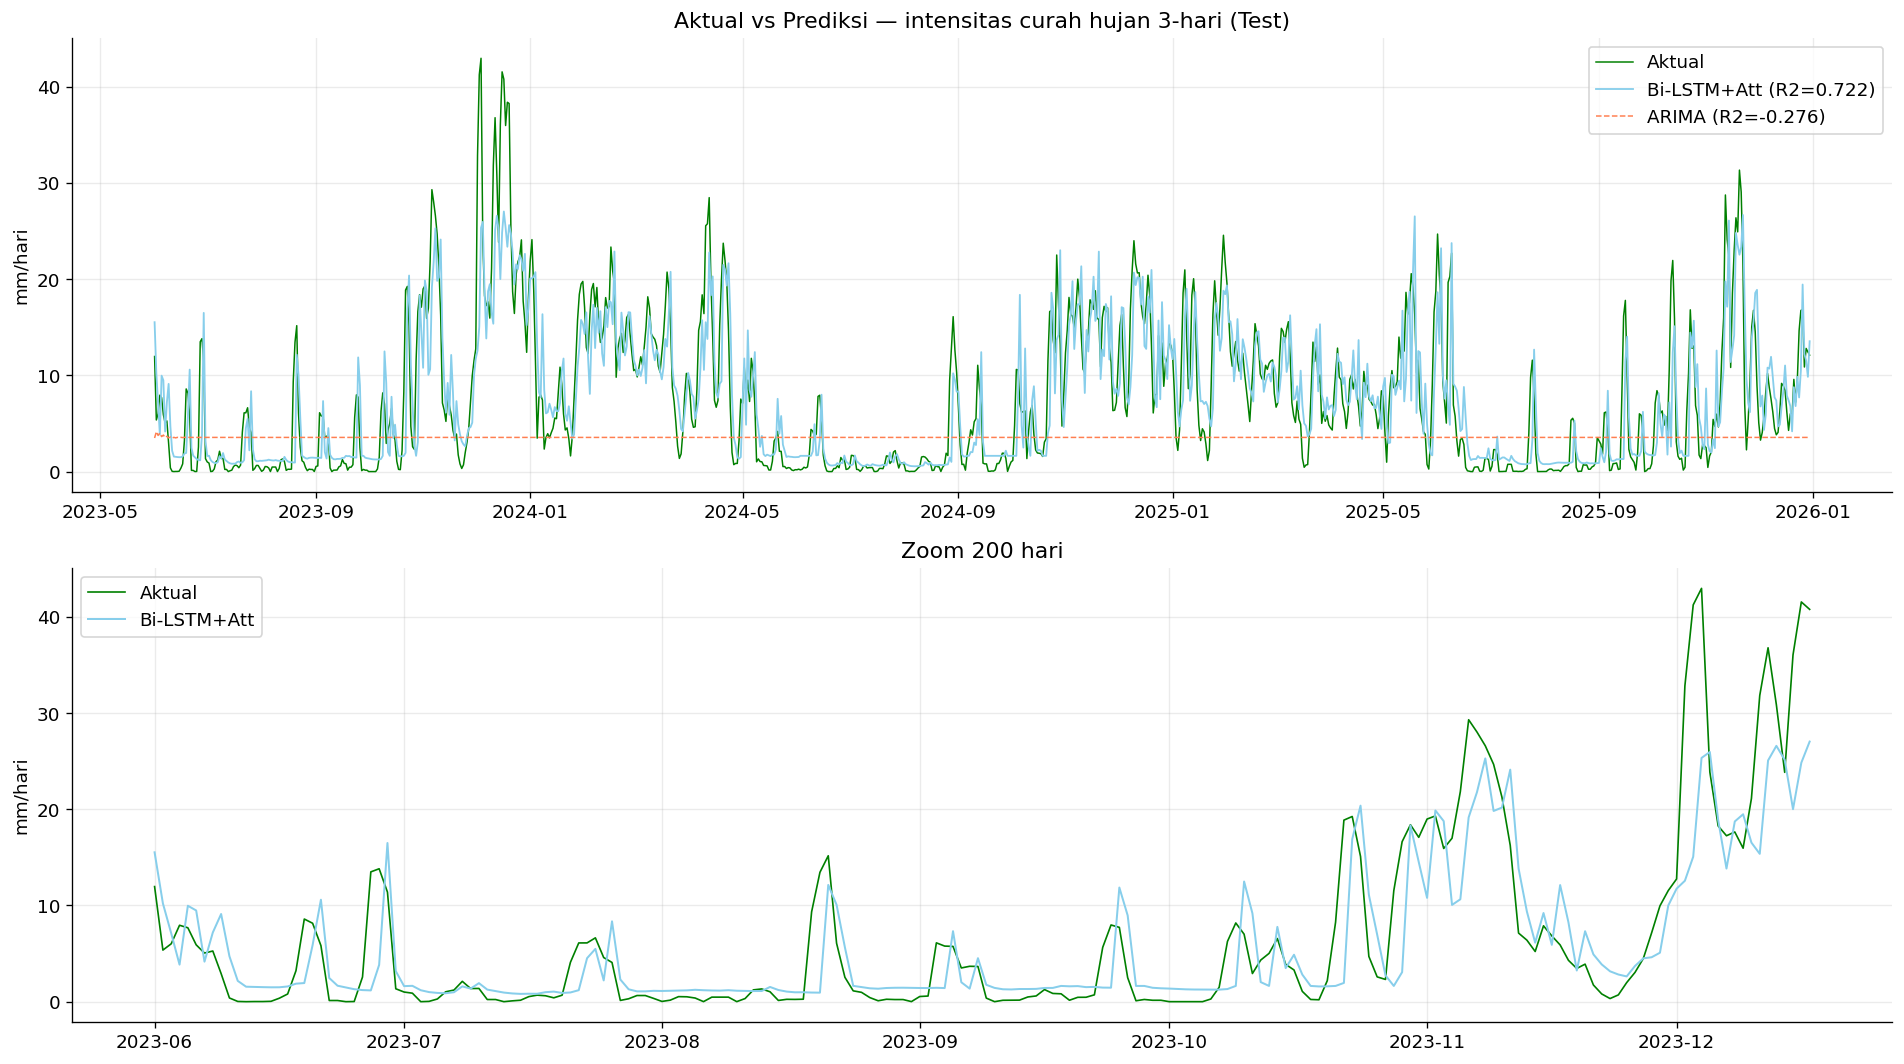

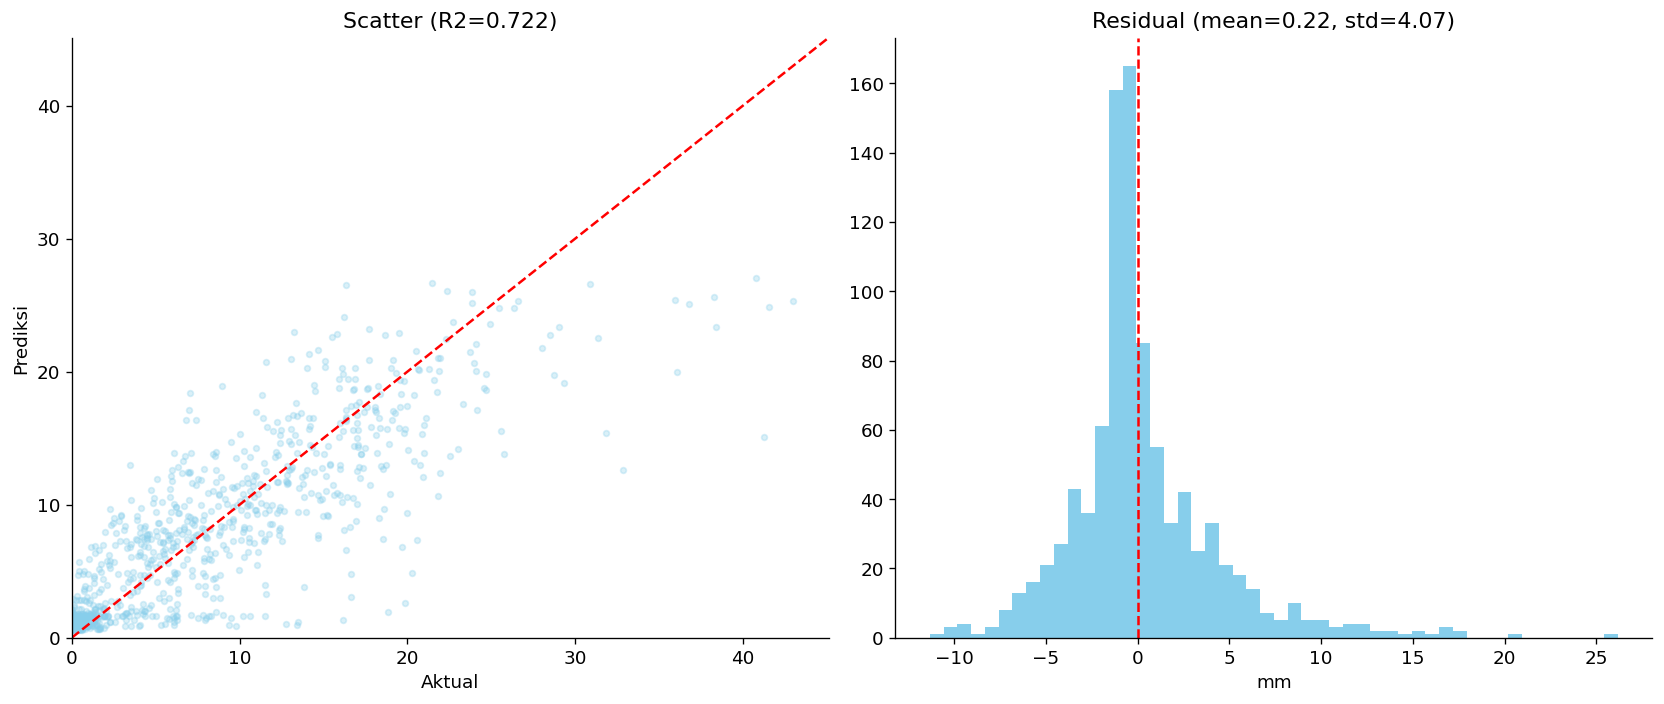

In [ ]:
# ================================================================
# SEL 11: PLOT HASIL
# ================================================================
dt=pd.to_datetime(dte)
fig,ax=plt.subplots(2,1,figsize=(16,9))
ax[0].plot(dt,y_test,color='green',lw=.9,label='Aktual')
ax[0].plot(dt,pred_test,color='skyblue',lw=1.1,label=f'Bi-LSTM+Att (R2={r2_bi:.3f})')
ax[0].plot(dt,arima_test,color='coral',lw=.9,ls='--',label=f'ARIMA (R2={r2_ar:.3f})')
ax[0].set_title('Aktual vs Prediksi — intensitas curah hujan 3-hari (Test)')
ax[0].set_ylabel('mm/hari'); ax[0].legend(); ax[0].grid(alpha=.25)
n=200
ax[1].plot(dt[:n],y_test[:n],color='green',lw=1,label='Aktual')
ax[1].plot(dt[:n],pred_test[:n],color='skyblue',lw=1.2,label='Bi-LSTM+Att')
ax[1].set_title('Zoom 200 hari'); ax[1].set_ylabel('mm/hari'); ax[1].legend(); ax[1].grid(alpha=.25)
plt.tight_layout(); plt.savefig('rev_plot_02_pred.png',dpi=150,bbox_inches='tight'); plt.show()

fig,ax=plt.subplots(1,2,figsize=(14,6))
lim=max(y_test.max(),pred_test.max())*1.05
ax[0].scatter(y_test,pred_test,alpha=.3,s=12,color='skyblue')
ax[0].plot([0,lim],[0,lim],'r--'); ax[0].set_xlim(0,lim); ax[0].set_ylim(0,lim)
ax[0].set_title(f'Scatter (R2={r2_bi:.3f})'); ax[0].set_xlabel('Aktual'); ax[0].set_ylabel('Prediksi')
res=y_test-pred_test
ax[1].hist(res,bins=50,color='skyblue'); ax[1].axvline(0,color='r',ls='--')
ax[1].set_title(f'Residual (mean={res.mean():.2f}, std={res.std():.2f})'); ax[1].set_xlabel('mm')
plt.tight_layout(); plt.savefig('rev_plot_03_scatter.png',dpi=150,bbox_inches='tight'); plt.show()


## SEL 13 — Ringkasan & ekspor

In [ ]:
# ================================================================
# SEL 13: RINGKASAN AKHIR
# ================================================================
print('='*64)
print('RINGKASAN — Bi-LSTM + Attention (target intensitas 3-hari)')
print('='*64)
print(f'Dataset       : CHIRPS NetCDF 3D Jawa Barat 2000-2025')
print(f'Fitur         : {N_FEATURES} (spasial+rolling+siklikal) | Timestep {TIMESTEP} hari')
print(f'Target        : rata-rata curah hujan {HORIZON} hari ke depan')
print()
print(f'  Bi-LSTM+Att : R2={r2_bi:.4f} MAE={mae_bi:.3f} RMSE={rmse_bi:.3f}')
print(f'  Auto-ARIMA  : R2={r2_ar:.4f} MAE={mae_ar:.3f} RMSE={rmse_ar:.3f}')
print(f'  Persistence : R2={r2_ps:.4f} MAE={mae_ps:.3f} RMSE={rmse_ps:.3f}')
print(f'  WFV 5-fold  : R2={wfv.R2.mean():.4f} +/- {wfv.R2.std():.4f}')
print('='*64)

pd.DataFrame({'Tanggal':pd.to_datetime(dte).strftime('%Y-%m-%d'),
              'Aktual':y_test.round(3),'Pred_BiLSTM':pred_test.round(3),
              'Pred_ARIMA':arima_test.round(3)}).to_csv('rev_hasil_prediksi.csv',index=False)
tbl.to_csv('rev_tabel_metrik.csv',index=False)
print('Tersimpan: rev_hasil_prediksi.csv, rev_tabel_metrik.csv, dan plot rev_*.png')


RINGKASAN — Bi-LSTM + Attention (target intensitas 3-hari)
Dataset       : CHIRPS NetCDF 3D Jawa Barat 2000-2025
Fitur         : 48 (spasial+rolling+siklikal) | Timestep 30 hari
Target        : rata-rata curah hujan 3 hari ke depan

  Bi-LSTM+Att : R2=0.7222 MAE=2.749 RMSE=4.077
  Auto-ARIMA  : R2=-0.2764 MAE=6.231 RMSE=8.739
  Persistence : R2=0.3573 MAE=4.379 RMSE=6.201
  WFV 5-fold  : R2=0.5816 +/- 0.1253
Tersimpan: rev_hasil_prediksi.csv, rev_tabel_metrik.csv, dan plot rev_*.png


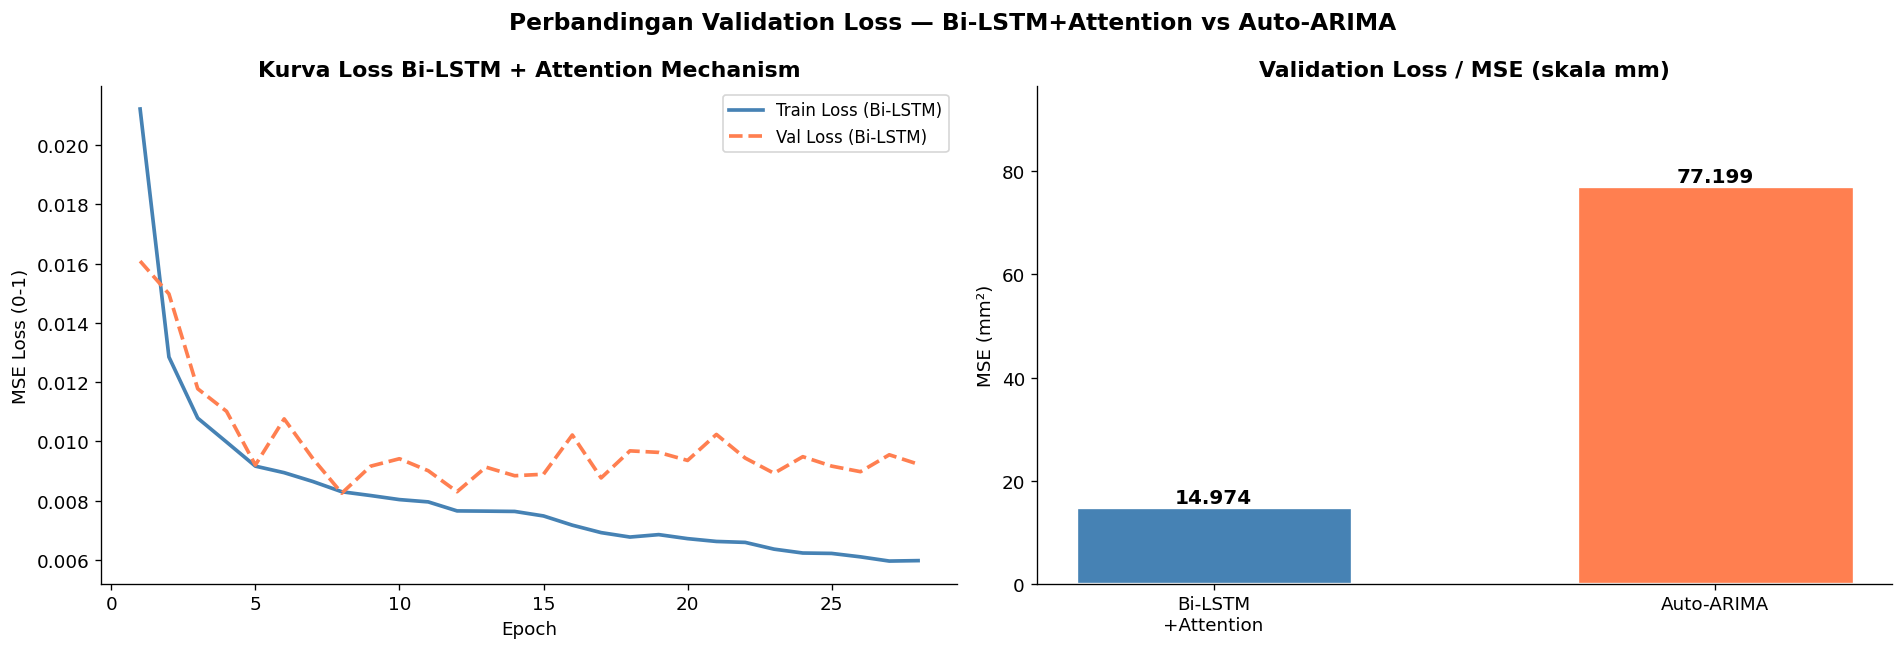

Val MSE  -> Bi-LSTM: 14.974 | ARIMA: 77.199
Val MAE  -> Bi-LSTM: 2.857 | ARIMA: 7.000
Catatan: ARIMA tak punya epoch, jadi dibandingkan via val-loss agregat (benar metodologis).


In [ ]:
# ================================================================
# SEL V1: VALIDATION LOSS — Bi-LSTM (kurva per-epoch) vs ARIMA (garis MSE)
# ================================================================
# MSE di data VALIDASI (skala mm asli) utk kedua model -> pembanding adil
val_mse_bi = mean_squared_error(y_val, pred_val)
val_mse_ar = mean_squared_error(y_val, arima_val)
val_mae_bi = mean_absolute_error(y_val, pred_val)
val_mae_ar = mean_absolute_error(y_val, arima_val)

# Define colors if not already defined (assuming these are constants)
C_BILSTM = '#4682B4' # SteelBlue
C_ARIMA  = '#FF7F50' # Coral

fig, ax = plt.subplots(1, 2, figsize=(16, 5.5))
fig.suptitle('Perbandingan Validation Loss — Bi-LSTM+Attention vs Auto-ARIMA',
             fontsize=14, fontweight='bold')

# (kiri) kurva loss per-epoch Bi-LSTM + garis acuan ARIMA
ep = range(1, len(history.history['loss']) + 1)
ax[0].plot(ep, history.history['loss'],     color=C_BILSTM, lw=2.2, label='Train Loss (Bi-LSTM)')
ax[0].plot(ep, history.history['val_loss'], color=C_ARIMA,  lw=2.2, ls='--', label='Val Loss (Bi-LSTM)')
ax[0].set_title('Kurva Loss Bi-LSTM + Attention Mechanism', fontweight='bold')
ax[0].set_xlabel('Epoch'); ax[0].set_ylabel('MSE Loss (0-1)')
ax[0].legend(fontsize=10)

# (kanan) bar val-loss kedua model di skala mm asli
bars = ax[1].bar(['Bi-LSTM\n+Attention', 'Auto-ARIMA'], [val_mse_bi, val_mse_ar],
                 color=[C_BILSTM, C_ARIMA], width=0.55, edgecolor='white', linewidth=2)
for b, v in zip(bars, [val_mse_bi, val_mse_ar]):
    ax[1].text(b.get_x()+b.get_width()/2, b.get_height(), f'{v:.3f}',
               ha='center', va='bottom', fontsize=12, fontweight='bold')
ax[1].set_title('Validation Loss / MSE (skala mm)', fontweight='bold')
ax[1].set_ylabel('MSE (mm²)')
ax[1].set_ylim(0, max(val_mse_bi, val_mse_ar)*1.25)

plt.tight_layout()
plt.savefig('viz_V1_val_loss_dua_model.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Val MSE  -> Bi-LSTM: {val_mse_bi:.3f} | ARIMA: {val_mse_ar:.3f}')
print(f'Val MAE  -> Bi-LSTM: {val_mae_bi:.3f} | ARIMA: {val_mae_ar:.3f}')
print('Catatan: ARIMA tak punya epoch, jadi dibandingkan via val-loss agregat (benar metodologis).')

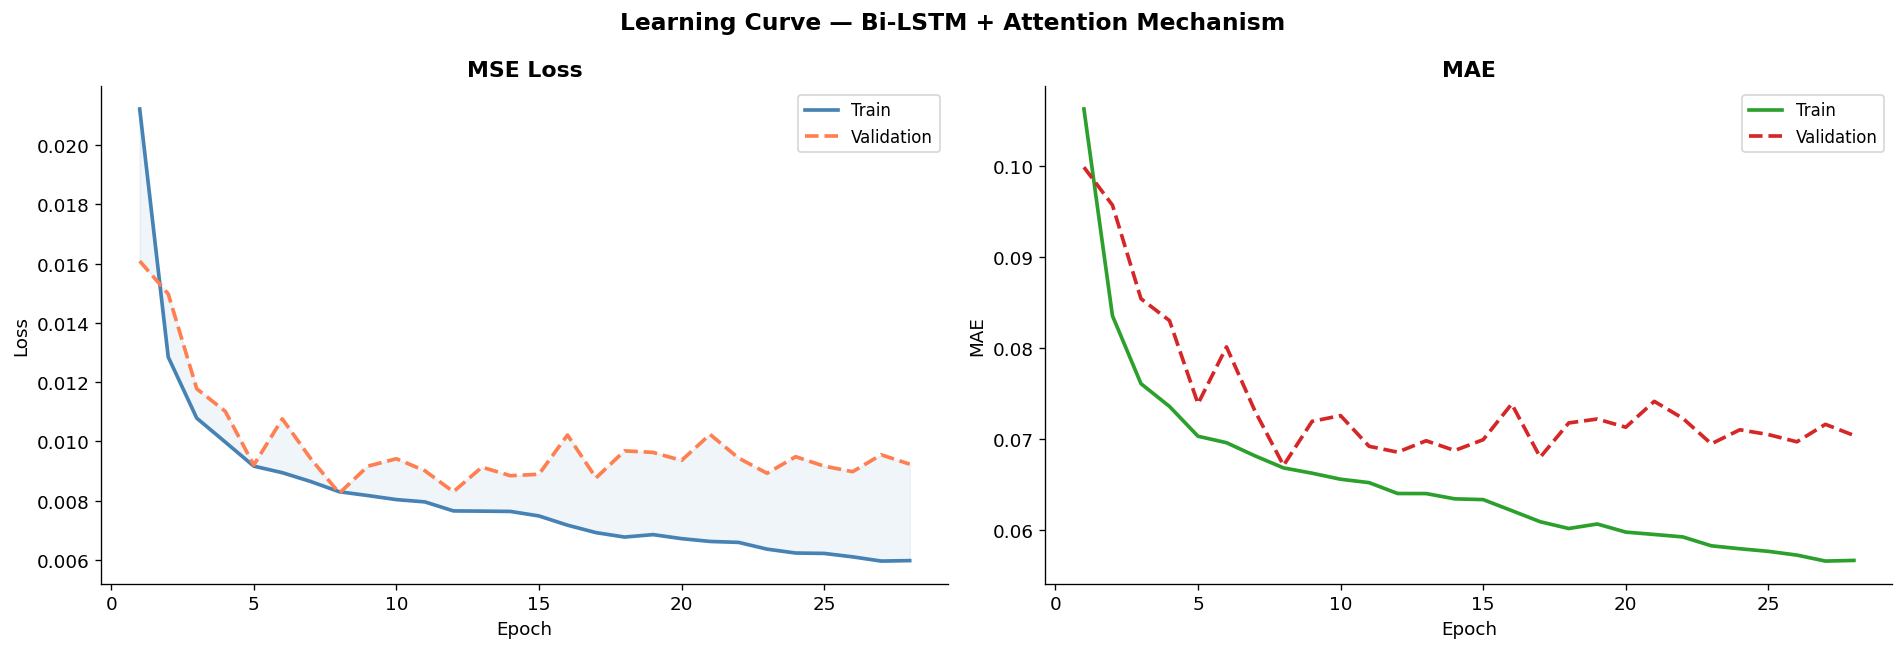

In [ ]:
# ================================================================
# SEL V2: LEARNING CURVE Bi-LSTM (train vs validation)
# ================================================================
fig, ax = plt.subplots(1, 2, figsize=(16, 5.5))
fig.suptitle('Learning Curve — Bi-LSTM + Attention Mechanism', fontsize=14, fontweight='bold')
ep = range(1, len(history.history['loss']) + 1)

# Define colors for this plot
C_GREEN = '#2CA02C' # Green
C_RED   = '#D62728' # Red

ax[0].plot(ep, history.history['loss'],     color=C_BILSTM, lw=2.2, label='Train')
ax[0].plot(ep, history.history['val_loss'], color=C_ARIMA,  lw=2.2, ls='--', label='Validation')
ax[0].fill_between(ep, history.history['loss'], history.history['val_loss'], color=C_BILSTM, alpha=0.08)
ax[0].set_title('MSE Loss', fontweight='bold'); ax[0].set_xlabel('Epoch'); ax[0].set_ylabel('Loss')
ax[0].legend(fontsize=10)

ax[1].plot(ep, history.history['mae'],     color=C_GREEN, lw=2.2, label='Train')
ax[1].plot(ep, history.history['val_mae'], color=C_RED,   lw=2.2, ls='--', label='Validation')
ax[1].set_title('MAE', fontweight='bold'); ax[1].set_xlabel('Epoch'); ax[1].set_ylabel('MAE')
ax[1].legend(fontsize=10)

plt.tight_layout()
plt.savefig('viz_V2_learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()

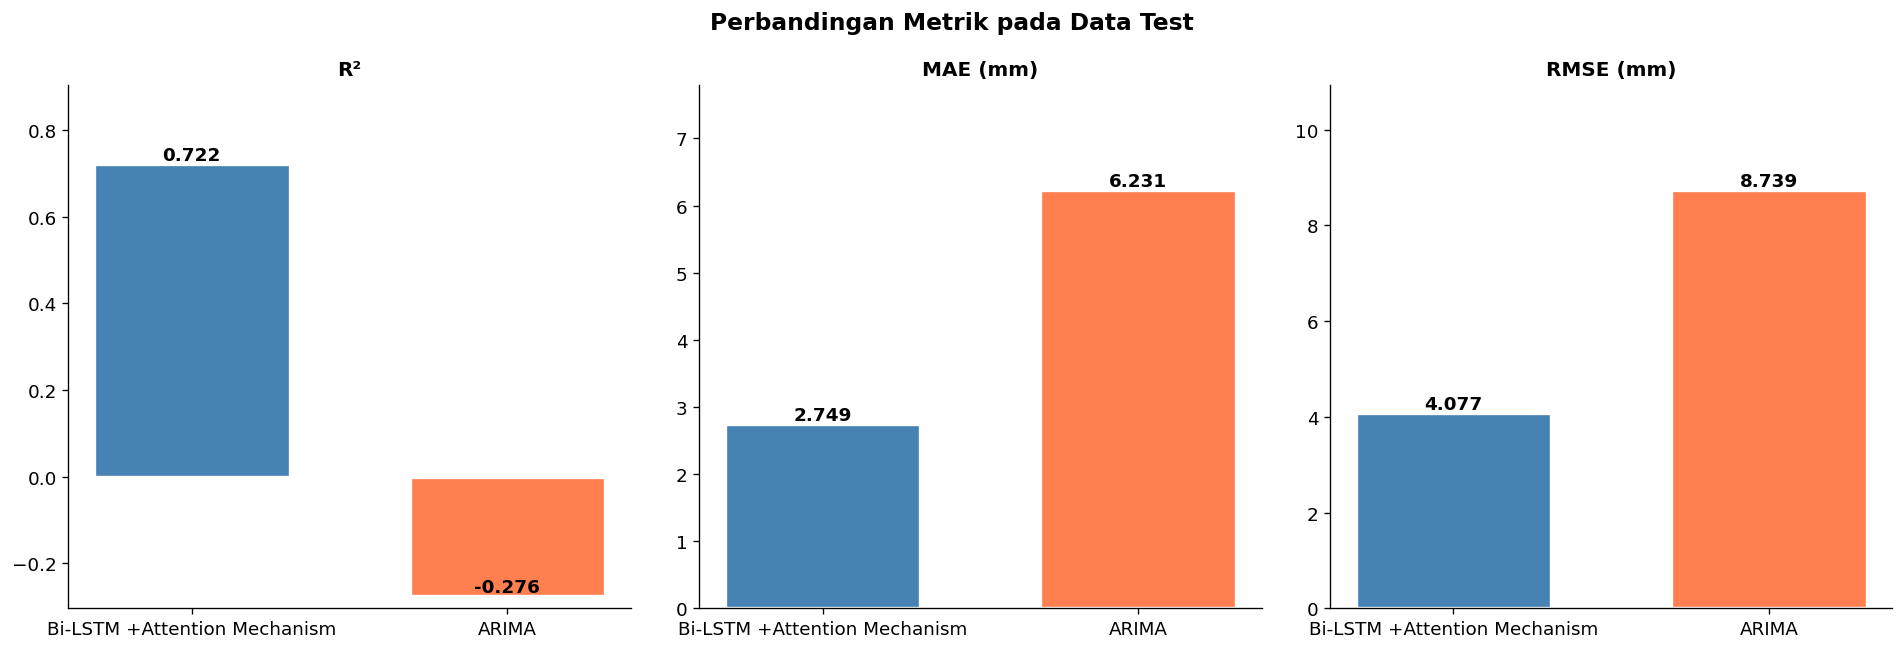

In [ ]:
# ================================================================
# SEL V3: BAR PERBANDINGAN METRIK — 3 model di data TEST
# ================================================================
# Define C_PERSIST color if not already defined
C_PERSIST = '#7F7F7F' # Grey

labels = ['Bi-LSTM +Attention Mechanism', 'ARIMA']
cols   = [C_BILSTM, C_ARIMA ]
groups = [('R²', [r2_bi, r2_ar ]),
          ('MAE (mm)', [mae_bi, mae_ar]),
          ('RMSE (mm)', [rmse_bi, rmse_ar])]

fig, ax = plt.subplots(1, 3, figsize=(16, 5.5))
fig.suptitle('Perbandingan Metrik pada Data Test', fontsize=14, fontweight='bold')
for a, (t, vals) in zip(ax, groups):
    bars = a.bar(labels, vals, color=cols, edgecolor='white', linewidth=2, width=0.62)
    for b, v in zip(bars, vals):
        a.text(b.get_x()+b.get_width()/2, b.get_height(), f'{v:.3f}',
               ha='center', va='bottom', fontsize=11, fontweight='bold')
    a.set_title(t, fontsize=12, fontweight='bold')
    a.set_ylim(min(0, min(vals)*1.1), max(vals)*1.25)
plt.tight_layout()
plt.savefig('viz_V3_metrik_perbandingan.png', dpi=150, bbox_inches='tight')
plt.show()

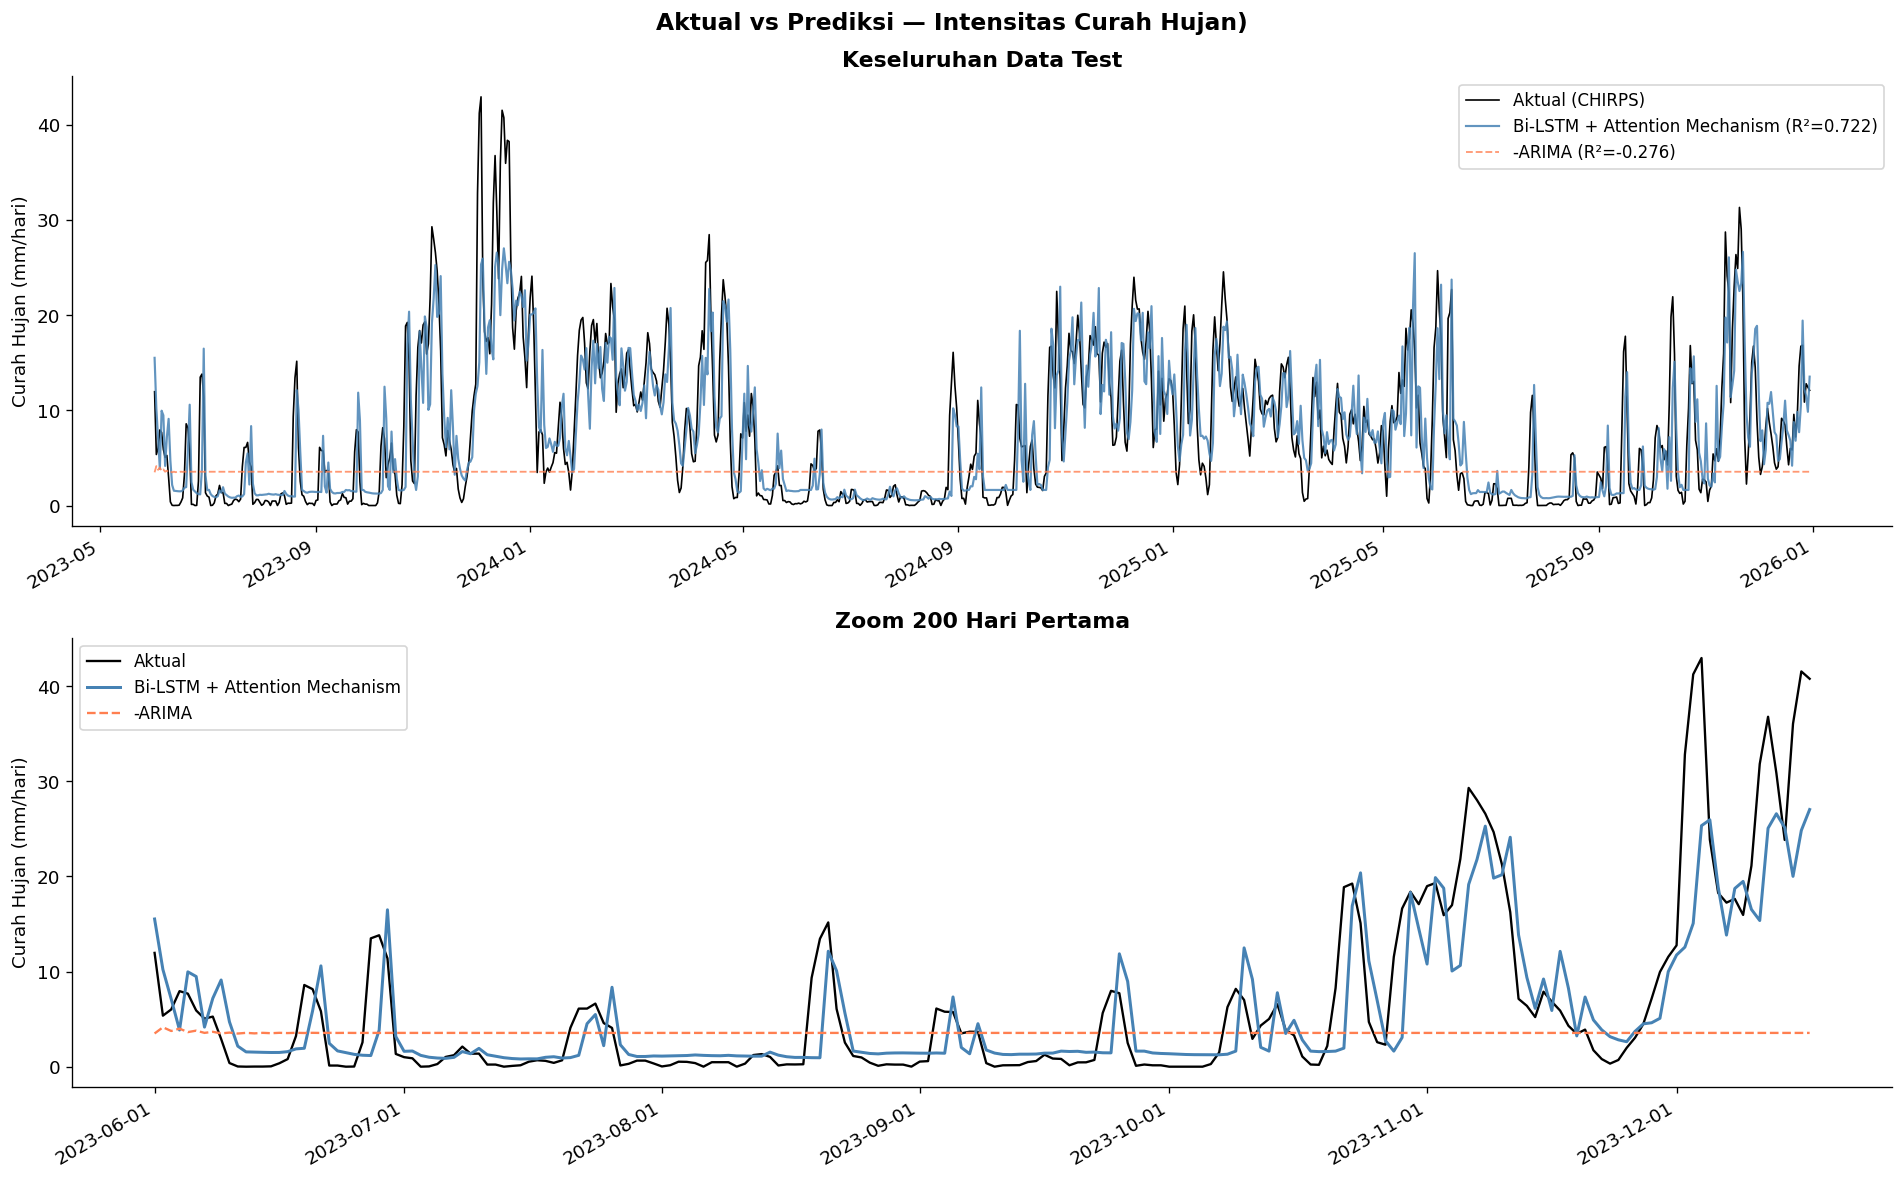

In [ ]:
# ================================================================
# SEL V4: AKTUAL vs PREDIKSI — Bi-LSTM & ARIMA bersamaan
# ================================================================
# Define colors for this plot
C_ACTUAL = '#000000' # Black

dt = pd.to_datetime(dte)
fig, ax = plt.subplots(2, 1, figsize=(16, 10))
fig.suptitle('Aktual vs Prediksi — Intensitas Curah Hujan)',
             fontsize=14, fontweight='bold')

ax[0].plot(dt, y_test,     color=C_ACTUAL, lw=1.0, label='Aktual (CHIRPS)')
ax[0].plot(dt, pred_test,  color=C_BILSTM, lw=1.3, alpha=0.85, label=f'Bi-LSTM + Attention Mechanism (R²={r2_bi:.3f})')
ax[0].plot(dt, arima_test, color=C_ARIMA,  lw=1.1, ls='--', alpha=0.8, label=f'-ARIMA (R²={r2_ar:.3f})')
ax[0].set_title('Keseluruhan Data Test', fontweight='bold')
ax[0].set_ylabel('Curah Hujan (mm/hari)'); ax[0].legend(fontsize=10)
ax[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax[0].get_xticklabels(), rotation=30, ha='right')

n = 200
ax[1].plot(dt[:n], y_test[:n],     color=C_ACTUAL, lw=1.4, label='Aktual')
ax[1].plot(dt[:n], pred_test[:n],  color=C_BILSTM, lw=1.8, label='Bi-LSTM + Attention Mechanism')
ax[1].plot(dt[:n], arima_test[:n], color=C_ARIMA,  lw=1.4, ls='--', label='-ARIMA')
ax[1].set_title('Zoom 200 Hari Pertama', fontweight='bold')
ax[1].set_ylabel('Curah Hujan (mm/hari)'); ax[1].legend(fontsize=10)
ax[1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m-%d'))
plt.setp(ax[1].get_xticklabels(), rotation=30, ha='right')

plt.tight_layout()
plt.savefig('viz_V4_aktual_vs_prediksi.png', dpi=150, bbox_inches='tight')
plt.show()

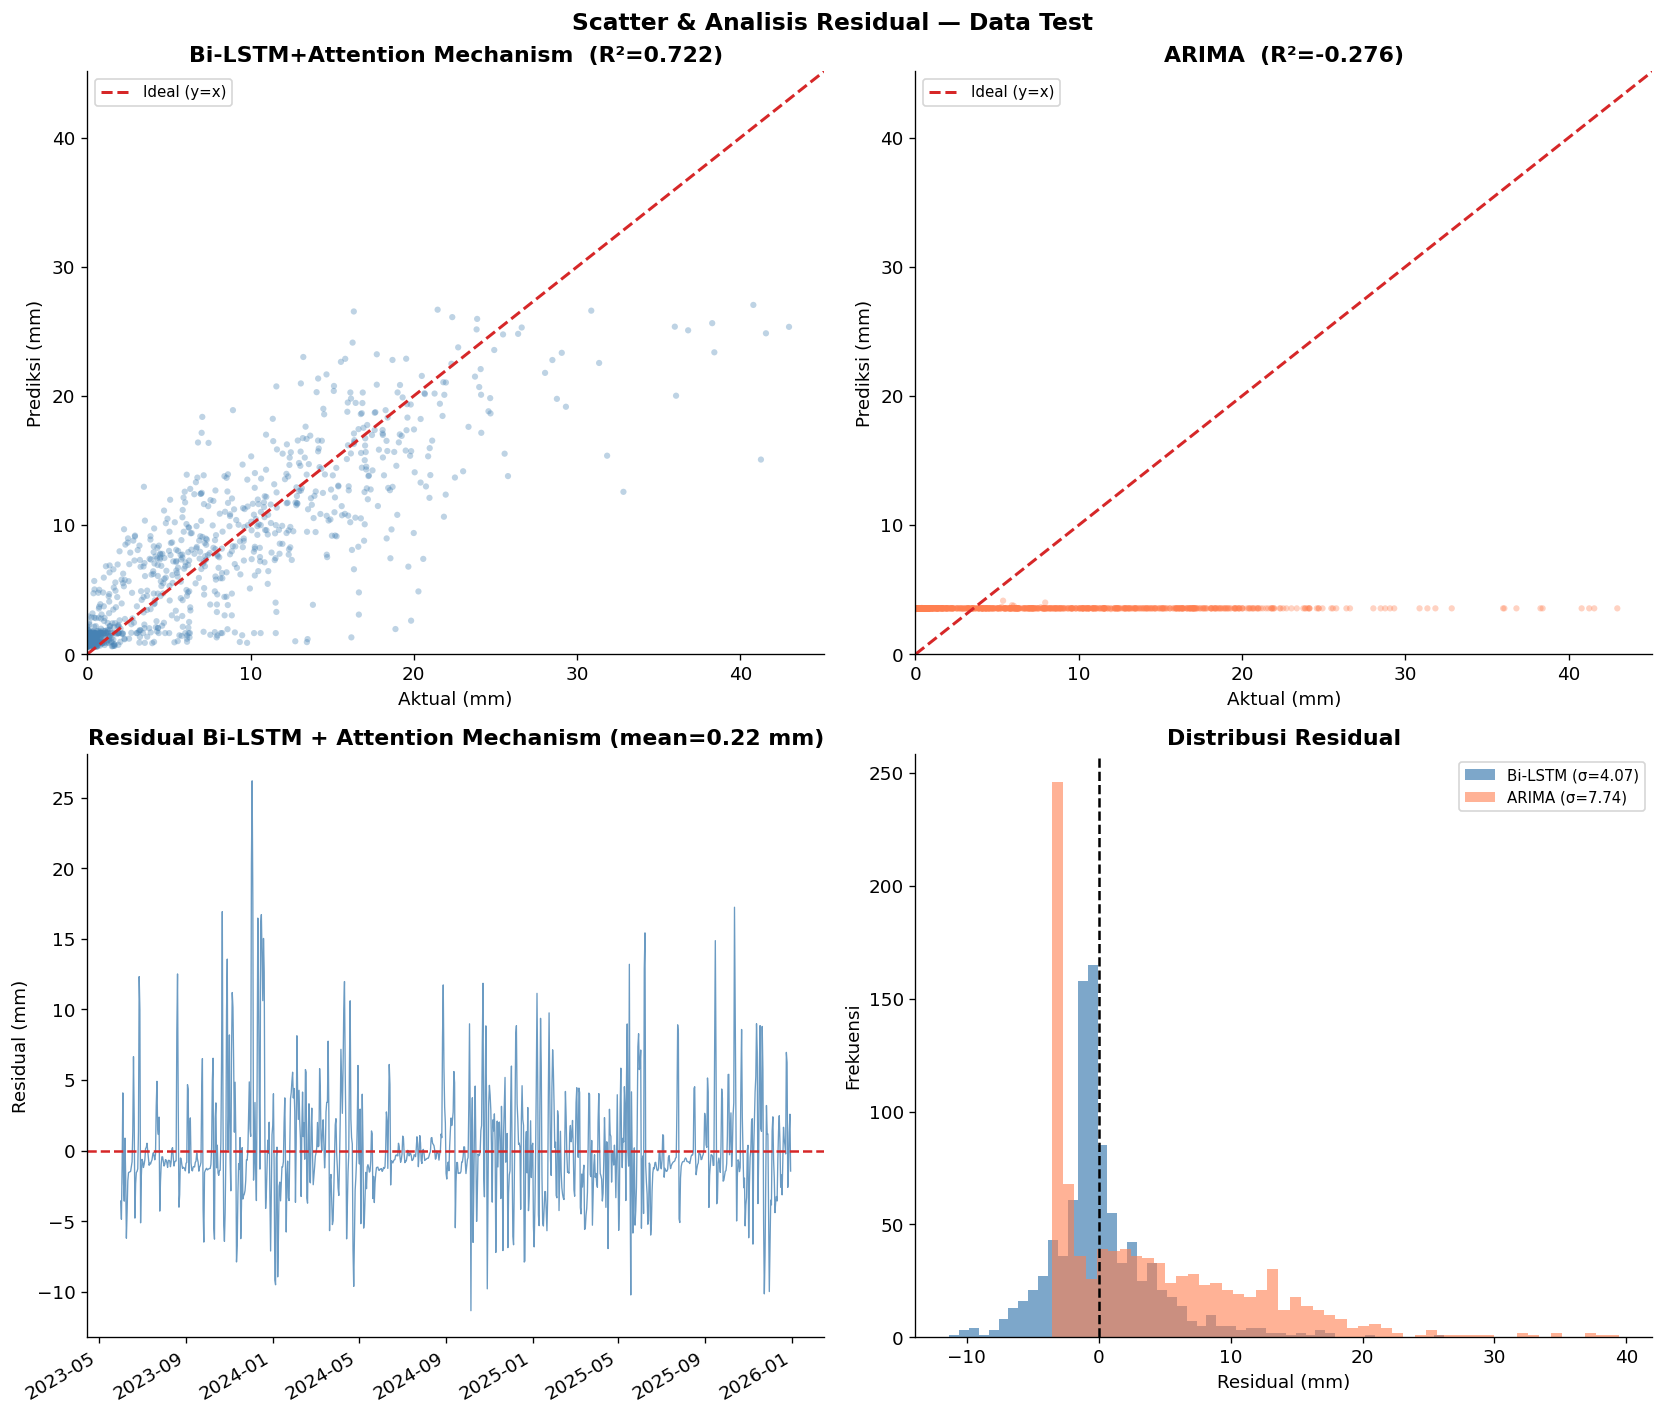

In [ ]:
# ================================================================
# SEL V5: SCATTER (Bi-LSTM & ARIMA) + DISTRIBUSI RESIDUAL
# ================================================================
fig, ax = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Scatter & Analisis Residual — Data Test', fontsize=14, fontweight='bold')
lim = max(y_test.max(), pred_test.max(), arima_test.max()) * 1.05

ax[0,0].scatter(y_test, pred_test, alpha=0.35, s=14, color=C_BILSTM, edgecolors='none')
ax[0,0].plot([0,lim],[0,lim], color=C_RED, ls='--', lw=1.8, label='Ideal (y=x)')
ax[0,0].set_title(f'Bi-LSTM+Attention Mechanism  (R²={r2_bi:.3f})', fontweight='bold')
ax[0,0].set_xlabel('Aktual (mm)'); ax[0,0].set_ylabel('Prediksi (mm)')
ax[0,0].set_xlim(0,lim); ax[0,0].set_ylim(0,lim); ax[0,0].legend(fontsize=9)

ax[0,1].scatter(y_test, arima_test, alpha=0.35, s=14, color=C_ARIMA, edgecolors='none')
ax[0,1].plot([0,lim],[0,lim], color=C_RED, ls='--', lw=1.8, label='Ideal (y=x)')
ax[0,1].set_title(f'ARIMA  (R²={r2_ar:.3f})', fontweight='bold')
ax[0,1].set_xlabel('Aktual (mm)'); ax[0,1].set_ylabel('Prediksi (mm)')
ax[0,1].set_xlim(0,lim); ax[0,1].set_ylim(0,lim); ax[0,1].legend(fontsize=9)

res_bi = y_test - pred_test
res_ar = y_test - arima_test
dt = pd.to_datetime(dte)
ax[1,0].plot(dt, res_bi, color=C_BILSTM, lw=0.8, alpha=0.8)
ax[1,0].axhline(0, color=C_RED, ls='--', lw=1.5)
ax[1,0].set_title(f'Residual Bi-LSTM + Attention Mechanism (mean={res_bi.mean():.2f} mm)', fontweight='bold')
ax[1,0].set_ylabel('Residual (mm)')
ax[1,0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.setp(ax[1,0].get_xticklabels(), rotation=30, ha='right')

ax[1,1].hist(res_bi, bins=50, alpha=0.7, color=C_BILSTM, label=f'Bi-LSTM (σ={res_bi.std():.2f})')
ax[1,1].hist(res_ar, bins=50, alpha=0.6, color=C_ARIMA,  label=f'ARIMA (σ={res_ar.std():.2f})')
ax[1,1].axvline(0, color=C_ACTUAL, ls='--', lw=1.5)
ax[1,1].set_title('Distribusi Residual', fontweight='bold')
ax[1,1].set_xlabel('Residual (mm)'); ax[1,1].set_ylabel('Frekuensi'); ax[1,1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('viz_V5_scatter_residual.png', dpi=150, bbox_inches='tight')
plt.show()


In [ ]:
# ================================================================
# SEL V6: EVALUASI per MUSIM (R² & MAE) + per KATEGORI HUJAN
# ================================================================
# Define C_TEAL color for this plot
C_TEAL = '#17BECF' # Teal

dfe = pd.DataFrame({'DateTime': pd.to_datetime(dte), 'Actual': y_test,
                    'BiLSTM': pred_test, 'ARIMA': arima_test})
dfe['Month']  = dfe['DateTime'].dt.month
dfe['Season'] = dfe['Month'].apply(lambda m: 'Musim Hujan\n(Nov–Mar)' if m in [11,12,1,2,3]
                                            else 'Musim Kemarau\n(Apr–Okt)')
dfe['Kategori'] = pd.cut(dfe['Actual'], bins=[-0.01,5,20,50,100,150,np.inf],
                         labels=['Tidak Hujan\n(0–5)','Ringan\n(5–20)','Sedang\n(20–50)',
                                 'Lebat\n(50–100)','Sangat Lebat\n(100–150)','Ekstrem\n(>150)'])

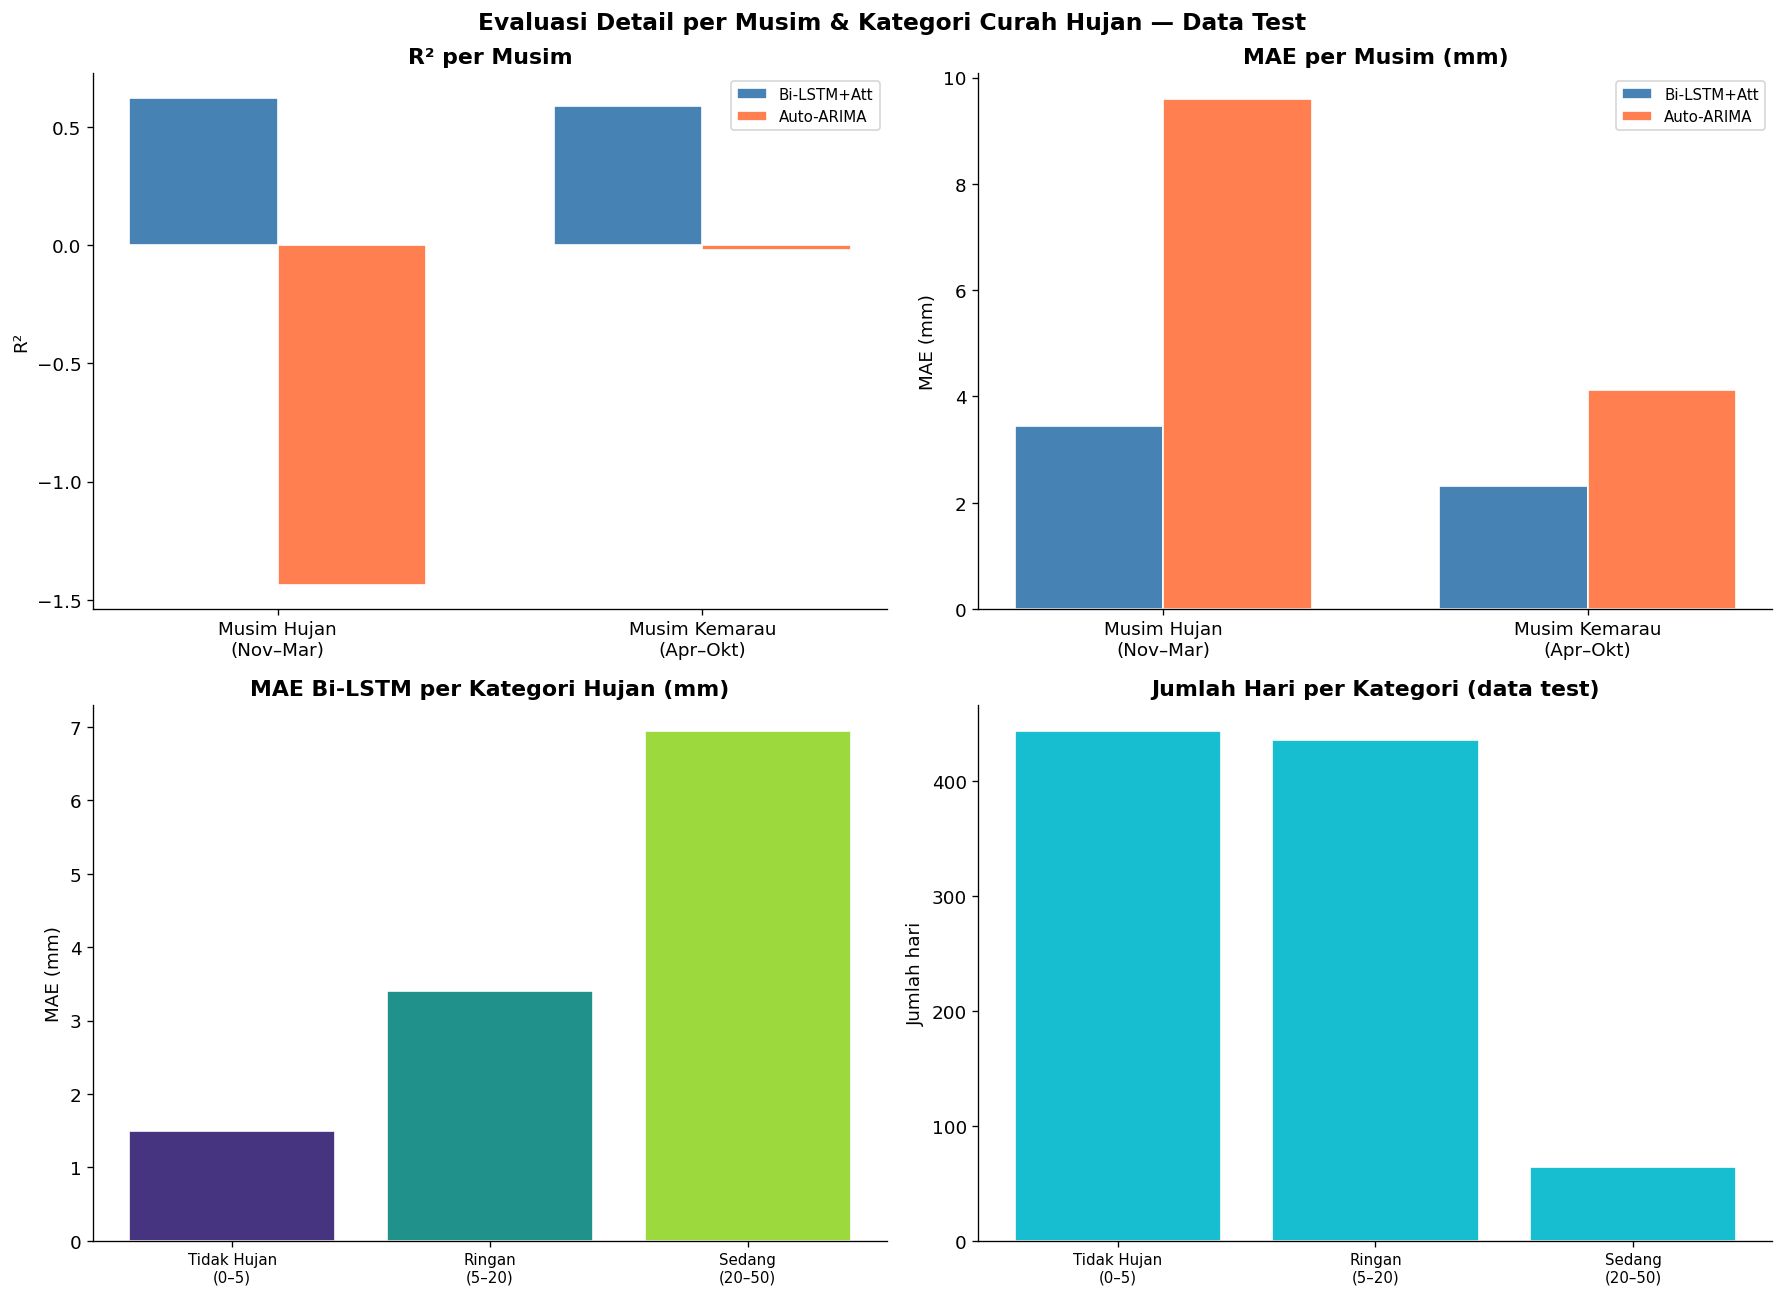

In [ ]:
sea_r2_bi  = dfe.groupby('Season').apply(lambda g: r2_score(g.Actual, g.BiLSTM))
sea_r2_ar  = dfe.groupby('Season').apply(lambda g: r2_score(g.Actual, g.ARIMA))
sea_mae_bi = dfe.groupby('Season').apply(lambda g: mean_absolute_error(g.Actual, g.BiLSTM))
sea_mae_ar = dfe.groupby('Season').apply(lambda g: mean_absolute_error(g.Actual, g.ARIMA))
cat_mae_bi = dfe.groupby('Kategori', observed=True).apply(lambda g: mean_absolute_error(g.Actual, g.BiLSTM))

fig, ax = plt.subplots(2, 2, figsize=(15, 11))
fig.suptitle('Evaluasi Detail per Musim & Kategori Curah Hujan — Data Test',
             fontsize=14, fontweight='bold')
seasons = sea_r2_bi.index.tolist(); x = np.arange(len(seasons)); w = 0.35

ax[0,0].bar(x-w/2, sea_r2_bi.values, w, color=C_BILSTM, edgecolor='white', label='Bi-LSTM+Att')
ax[0,0].bar(x+w/2, sea_r2_ar.values, w, color=C_ARIMA,  edgecolor='white', label='Auto-ARIMA')
ax[0,0].set_xticks(x); ax[0,0].set_xticklabels(seasons); ax[0,0].set_title('R² per Musim', fontweight='bold')
ax[0,0].set_ylabel('R²'); ax[0,0].legend(fontsize=9)

ax[0,1].bar(x-w/2, sea_mae_bi.values, w, color=C_BILSTM, edgecolor='white', label='Bi-LSTM+Att')
ax[0,1].bar(x+w/2, sea_mae_ar.values, w, color=C_ARIMA,  edgecolor='white', label='Auto-ARIMA')
ax[0,1].set_xticks(x); ax[0,1].set_xticklabels(seasons); ax[0,1].set_title('MAE per Musim (mm)', fontweight='bold')
ax[0,1].set_ylabel('MAE (mm)'); ax[0,1].legend(fontsize=9)

cats = cat_mae_bi.index.astype(str); xc = np.arange(len(cats))
barcols = plt.cm.viridis(np.linspace(0.15, 0.85, len(cats)))
ax[1,0].bar(xc, cat_mae_bi.values, color=barcols, edgecolor='white')
ax[1,0].set_xticks(xc); ax[1,0].set_xticklabels(cats, fontsize=9)
ax[1,0].set_title('MAE Bi-LSTM per Kategori Hujan (mm)', fontweight='bold'); ax[1,0].set_ylabel('MAE (mm)')

counts = dfe['Kategori'].value_counts().reindex(cat_mae_bi.index)
ax[1,1].bar(xc, counts.values, color=C_TEAL, edgecolor='white')
ax[1,1].set_xticks(xc); ax[1,1].set_xticklabels(cats, fontsize=9)
ax[1,1].set_title('Jumlah Hari per Kategori (data test)', fontweight='bold'); ax[1,1].set_ylabel('Jumlah hari')

plt.tight_layout()
plt.savefig('viz_V6_evaluasi_musim_kategori.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
last_8_days = dfe.tail(8)
display(last_8_days)

print('\nMin, Max, dan Mean untuk 8 Hari Terakhir:')
for col in ['Actual', 'BiLSTM', 'ARIMA']:
    print(f'{col}:')
    print(f'  Min: {last_8_days[col].min():.3f}')
    print(f'  Max: {last_8_days[col].max():.3f}')
    print(f'  Mean: {last_8_days[col].mean():.3f}')

,DateTime,Actual,BiLSTM,ARIMA,Month,Season,Kategori
936,2025-12-23,9.621212,9.847048,3.551487,12,Musim Hujan\n(Nov–Mar),Ringan\n(5–20)
937,2025-12-24,14.668199,7.707800,3.551487,12,Musim Hujan\n(Nov–Mar),Ringan\n(5–20)
938,2025-12-25,16.756210,10.519632,3.551487,12,Musim Hujan\n(Nov–Mar),Ringan\n(5–20)
939,2025-12-26,16.852542,19.447714,3.551487,12,Musim Hujan\n(Nov–Mar),Ringan\n(5–20)
940,2025-12-27,10.871172,12.230854,3.551487,12,Musim Hujan\n(Nov–Mar),Ringan\n(5–20)
941,2025-12-28,12.804673,11.535712,3.551487,12,Musim Hujan\n(Nov–Mar),Ringan\n(5–20)
942,2025-12-29,12.438148,9.853453,3.551487,12,Musim Hujan\n(Nov–Mar),Ringan\n(5–20)
943,2025-12-30,12.109629,13.551724,3.551487,12,Musim Hujan\n(Nov–Mar),Ringan\n(5–20)



Min, Max, dan Mean untuk 8 Hari Terakhir:
Actual:
  Min: 9.621
  Max: 16.853
  Mean: 13.265
BiLSTM:
  Min: 7.708
  Max: 19.448
  Mean: 11.837
ARIMA:
  Min: 3.551
  Max: 3.551
  Mean: 3.551


### Contoh Data 8 Hari Terakhir

In [ ]:
last_8_days = dfe.tail(8)
display(last_8_days)

print('\nMin, Max, dan Mean untuk 8 Hari Terakhir:')
for col in ['Actual', 'BiLSTM', 'ARIMA']:
    print(f'{col}:')
    print(f'  Min: {last_8_days[col].min():.3f}')
    print(f'  Max: {last_8_days[col].max():.3f}')
    print(f'  Mean: {last_8_days[col].mean():.3f}')

,DateTime,Actual,BiLSTM,ARIMA,Month,Season,Kategori
936,2025-12-23,9.621212,9.847048,3.551487,12,Musim Hujan\n(Nov–Mar),Ringan\n(5–20)
937,2025-12-24,14.668199,7.707800,3.551487,12,Musim Hujan\n(Nov–Mar),Ringan\n(5–20)
938,2025-12-25,16.756210,10.519632,3.551487,12,Musim Hujan\n(Nov–Mar),Ringan\n(5–20)
939,2025-12-26,16.852542,19.447714,3.551487,12,Musim Hujan\n(Nov–Mar),Ringan\n(5–20)
940,2025-12-27,10.871172,12.230854,3.551487,12,Musim Hujan\n(Nov–Mar),Ringan\n(5–20)
941,2025-12-28,12.804673,11.535712,3.551487,12,Musim Hujan\n(Nov–Mar),Ringan\n(5–20)
942,2025-12-29,12.438148,9.853453,3.551487,12,Musim Hujan\n(Nov–Mar),Ringan\n(5–20)
943,2025-12-30,12.109629,13.551724,3.551487,12,Musim Hujan\n(Nov–Mar),Ringan\n(5–20)



Min, Max, dan Mean untuk 8 Hari Terakhir:
Actual:
  Min: 9.621
  Max: 16.853
  Mean: 13.265
BiLSTM:
  Min: 7.708
  Max: 19.448
  Mean: 11.837
ARIMA:
  Min: 3.551
  Max: 3.551
  Mean: 3.551


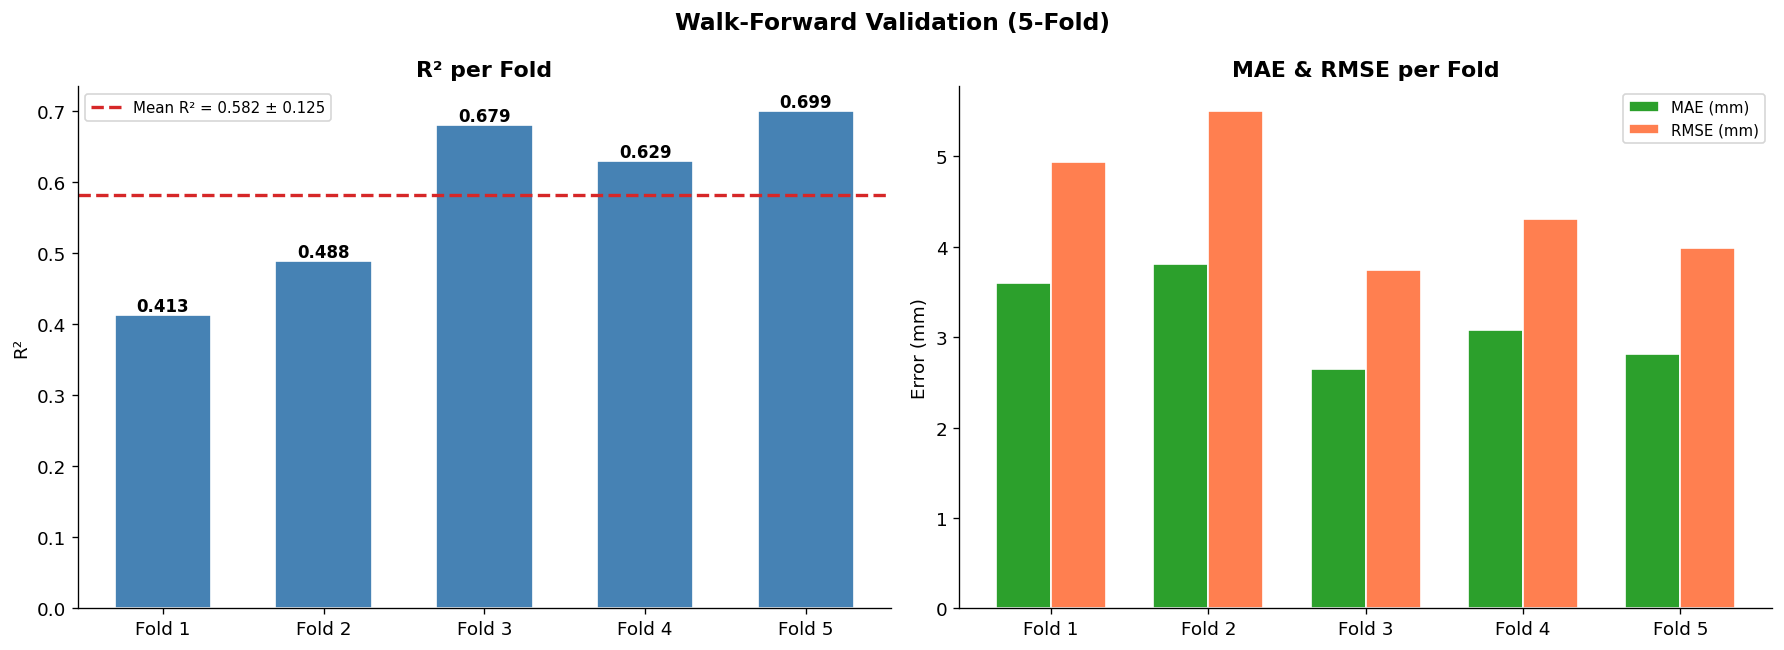

In [ ]:
# ================================================================
# SEL V7: WALK-FORWARD VALIDATION — R² per fold + rata-rata
# ================================================================
fig, ax = plt.subplots(1, 2, figsize=(15, 5.5))
fig.suptitle('Walk-Forward Validation (5-Fold)', fontsize=14, fontweight='bold')
x = np.arange(len(wfv))

bars = ax[0].bar(x, wfv['R2'], color=C_BILSTM, edgecolor='white', width=0.6)
for i, v in zip(x, wfv['R2']):
    ax[0].text(i, v, f'{v:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax[0].axhline(wfv['R2'].mean(), color=C_RED, ls='--', lw=2,
              label=f"Mean R² = {wfv['R2'].mean():.3f} ± {wfv['R2'].std():.3f}")
ax[0].set_xticks(x); ax[0].set_xticklabels([f'Fold {i}' for i in wfv['Fold']])
ax[0].set_ylabel('R²'); ax[0].set_title('R² per Fold', fontweight='bold'); ax[0].legend(fontsize=9)

w = 0.35
ax[1].bar(x-w/2, wfv['MAE'],  w, color=C_GREEN,  edgecolor='white', label='MAE (mm)')
ax[1].bar(x+w/2, wfv['RMSE'], w, color=C_ARIMA,  edgecolor='white', label='RMSE (mm)')
ax[1].set_xticks(x); ax[1].set_xticklabels([f'Fold {i}' for i in wfv['Fold']])
ax[1].set_ylabel('Error (mm)'); ax[1].set_title('MAE & RMSE per Fold', fontweight='bold'); ax[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('viz_V7_walk_forward.png', dpi=150, bbox_inches='tight')
plt.show()
